# NYC Taxi Fares — Exploratory Data Analysis

This notebook explores 500,000 NYC taxi trips (2009–2015), checks data quality, cleans the data, and then answers eight questions about what drives fares and demand.

In [ ]:
!pip install gdown
import gdown
import pandas as pd

url = "https://drive.google.com/file/d/13SXMNuaNrJznox9WanKkgPjRObSX6I8M/view"
gdown.download(url, "data.csv", fuzzy=True)
df = pd.read_csv("data.csv")

Downloading...
From (original): https://drive.google.com/uc?id=13SXMNuaNrJznox9WanKkgPjRObSX6I8M
From (redirected): https://drive.google.com/uc?id=13SXMNuaNrJznox9WanKkgPjRObSX6I8M&confirm=t&uuid=f437c589-4a42-4c41-9b8b-a64cf12b7f66
To: /content/data.csv
100%|██████████| 171M/171M [00:01<00:00, 86.1MB/s]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
SAMPLE = 50_000

### Inspecting Data Shape and Information

We check the shape and general summary of the DataFrame to understand dimensions, column data types, and presence of null values.

In [ ]:
print(f"DataFrame shape: {df.shape}")
df.info()

DataFrame shape: (500000, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                50

### Interpretation of Data Shape and Information

* **Dimensions**: 500,000 rows, 26 columns.
* **Types**: Mostly numerical (`float64`, `int64`) and some categorical/identifier objects.
* **Action Item**: `pickup_datetime` is currently a string and needs parsing.

### Checking for Missing Values

We count the number of missing (`NaN`) values per column to identify any features requiring imputation or removal.

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

Missing values per column:


,0
dropoff_longitude,5
dropoff_latitude,5
jfk_dist,5
ewr_dist,5
lga_dist,5
sol_dist,5
nyc_dist,5
distance,5
bearing,5


### Interpretation of Missing Values

Only nine spatial/geographical columns have missing entries, affecting just 5 rows (0.001% of the dataset). This minor issue will be handled by dropping these rows during data cleaning.

### Checking for Duplicate Rows

We check for exact duplicate rows to prevent skewed analysis and model overfitting.

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


### Interpretation of Duplicate Rows

No exact duplicate rows were found in the dataset.

### Checking for Constant Columns

We scan for columns containing only a single unique value, as they offer no predictive power.

In [ ]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
if len(constant_columns) > 0:
    print(f"Constant columns: {constant_columns}")
else:
    print("No constant columns found.")

No constant columns found.


### Interpretation of Constant Columns

No constant columns were detected; all columns contain variable data.

### Checking for Inconsistent Data Types

We inspect the data types of 'object' columns to ensure consistency and identify any mixed types.

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column '{col}':")
    display(df[col].apply(type).value_counts())


Column 'User ID':


,count
User ID,
<class 'str'>,500000


Column 'User Name':


,count
User Name,
<class 'str'>,500000


Column 'Driver Name':


...

,count
Traffic Condition,
<class 'str'>,500000


Column 'key':


,count
key,
<class 'str'>,500000


Column 'pickup_datetime':


,count
pickup_datetime,
<class 'str'>,500000


### Interpretation of Inconsistent Data Types

All 'object' columns consistently contain string values, meaning no mixed types are present. Temporal components (`hour`, `day`, etc.) are already pre-extracted as integers.

### Univariate Analysis: Numeric Features

We examine distributions, skewness, and kurtosis of key numeric columns to identify scaling issues and extreme outliers.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    print(f"\n--- Analysis for '{col}' ---")
    print("Descriptive Statistics:")
    display(df[col].describe())
    print(f"Skewness: {df[col].skew():.2f}")
    print(f"Kurtosis: {df[col].kurt():.2f}")


--- Analysis for 'fare_amount' ---
Descriptive Statistics:


,fare_amount
count,500000.000000
mean,11.358361
std,9.916617
min,-44.900000
25%,6.000000
50%,8.500000
75%,12.500000
max,500.000000


Skewness: 4.90
Kurtosis: 83.17

--- Analysis for 'pickup_longitude' ---
Descriptive Statistics:


,pickup_longitude
count,500000.000000
mean,-1.265712
std,0.206941
min,-52.119764
25%,-1.291405
50%,-1.291226
75%,-1.290970
max,37.360538


Skewness: -14.01
Kurtosis: 9867.57

--- Analysis for 'pickup_latitude' ---
Descriptive Statistics:


...

Skewness: 7.17
Kurtosis: 51.67

--- Analysis for 'distance' ---
Descriptive Statistics:


,distance
count,499995.000000
mean,19.468775
std,367.299601
min,0.000000
25%,1.214550
50%,2.116970
75%,3.890070
max,12399.956433


Skewness: 22.99
Kurtosis: 531.25

--- Analysis for 'bearing' ---
Descriptive Statistics:


,bearing
count,499995.000000
mean,0.297145
std,1.804548
min,-3.141593
25%,-0.854721
50%,-0.050442
75%,2.206769
max,3.141593


Skewness: -0.02
Kurtosis: -1.11


Distribution of each selected numeric feature using histograms.
Generating histogram for: fare_amount


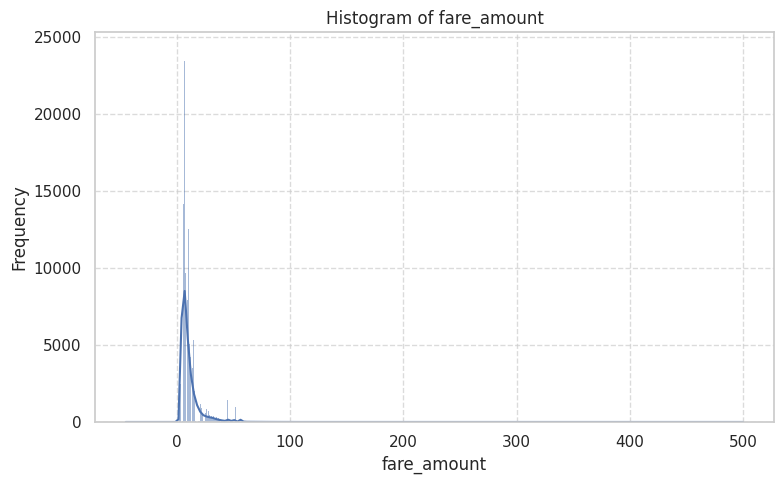

Generating histogram for: passenger_count


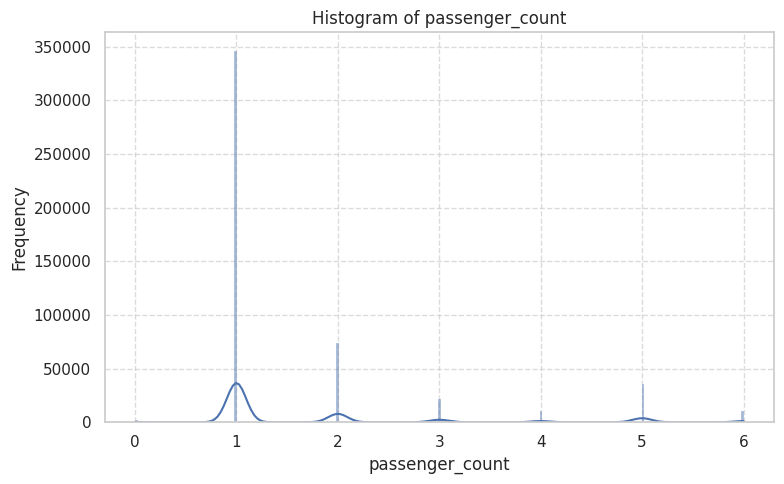

Generating histogram for: distance


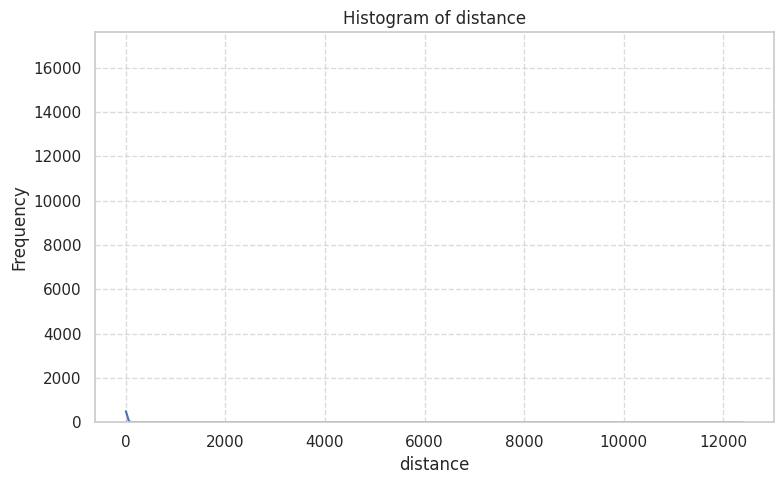

Generating histogram for: hour


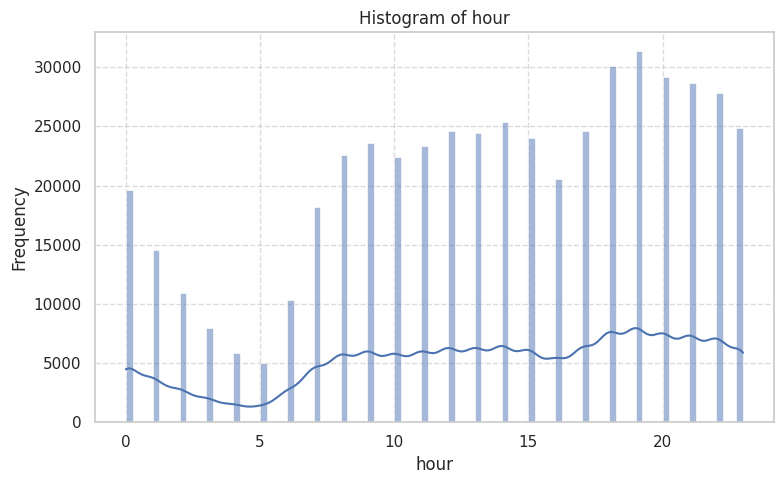

Generating histogram for: day


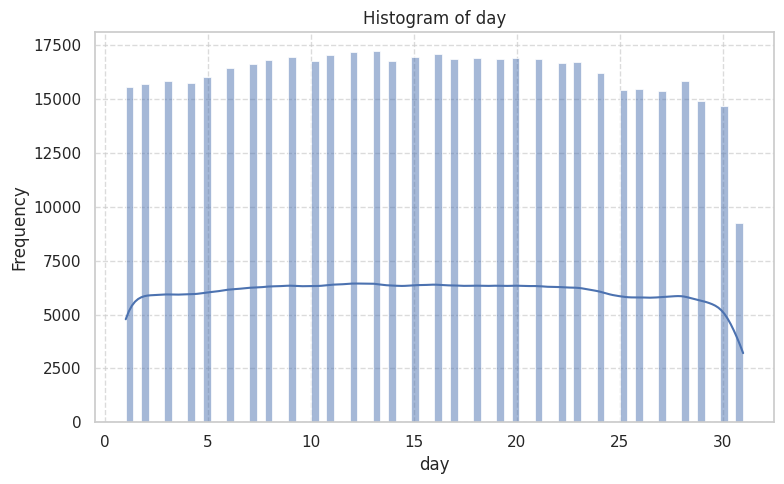

Generating histogram for: month


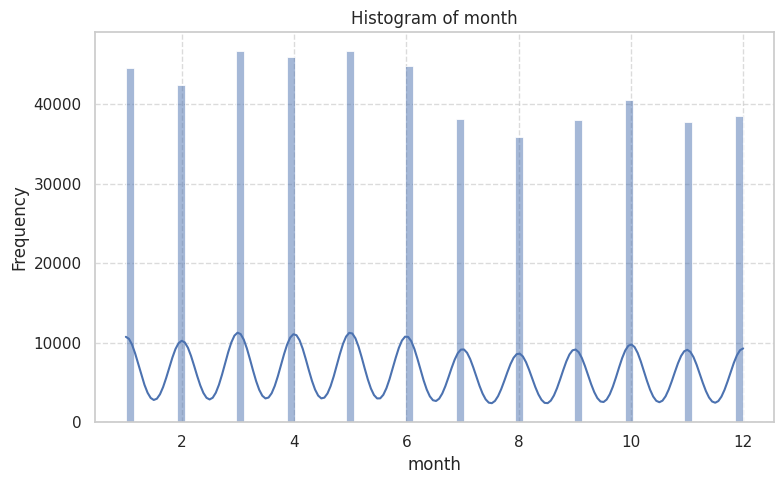

Generating histogram for: weekday


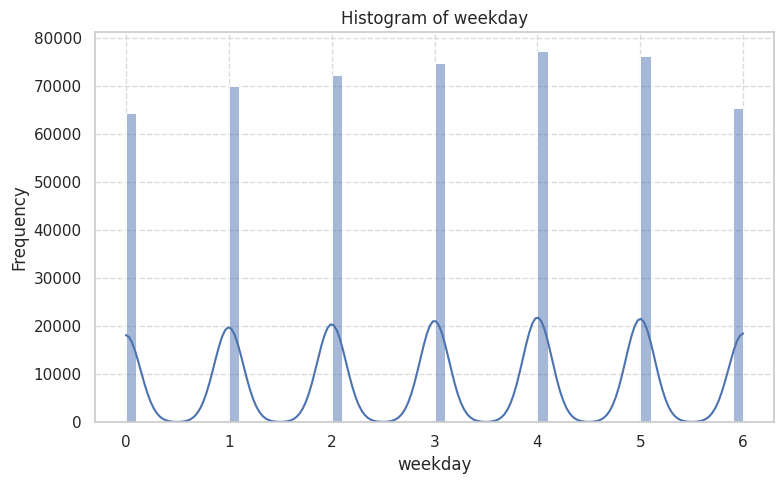

Generating histogram for: year


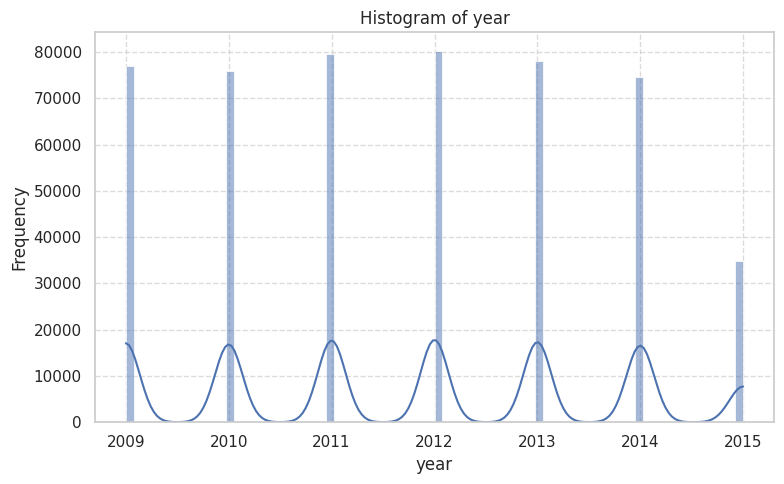

In [ ]:
numeric_cols = ['fare_amount', 'passenger_count', 'distance', 'hour', 'day', 'month', 'weekday', 'year']

print("Distribution of each selected numeric feature using histograms.")

for col in numeric_cols:
    print(f"Generating histogram for: {col}")
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Distribution and potential outliers of each selected numeric feature using box plots.
Generating box plot for: fare_amount


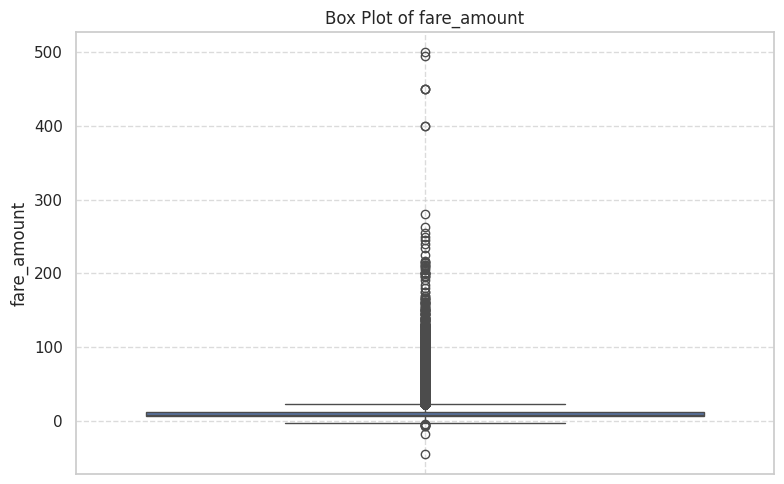

Generating box plot for: passenger_count


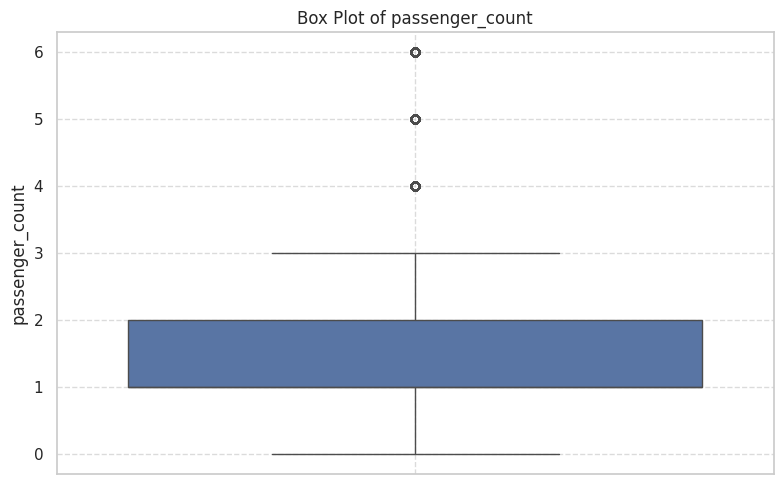

Generating box plot for: distance


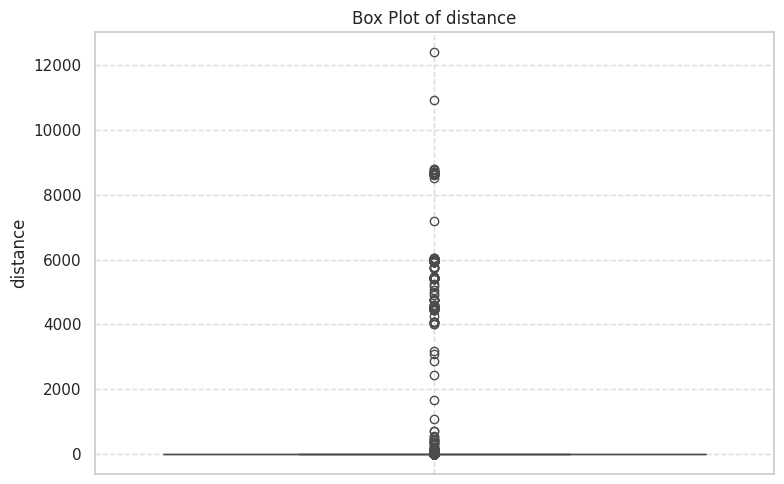

Generating box plot for: hour


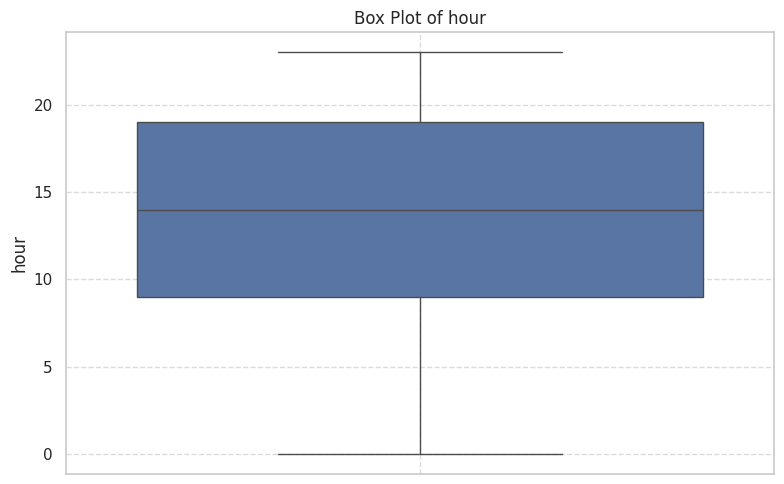

Generating box plot for: day


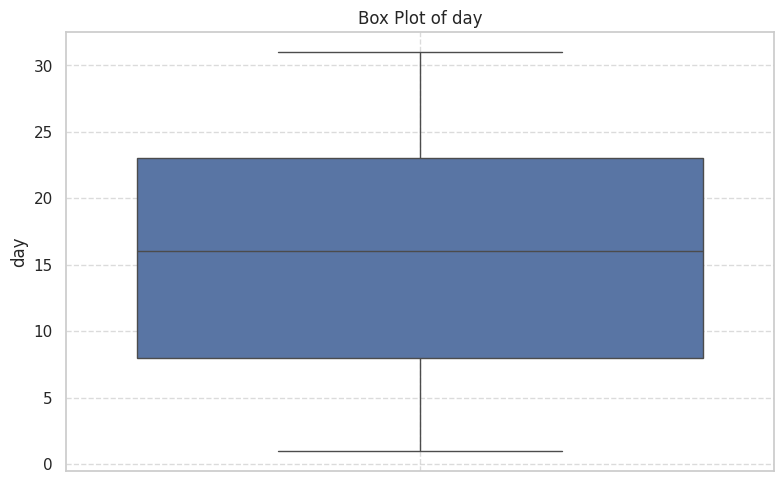

Generating box plot for: month


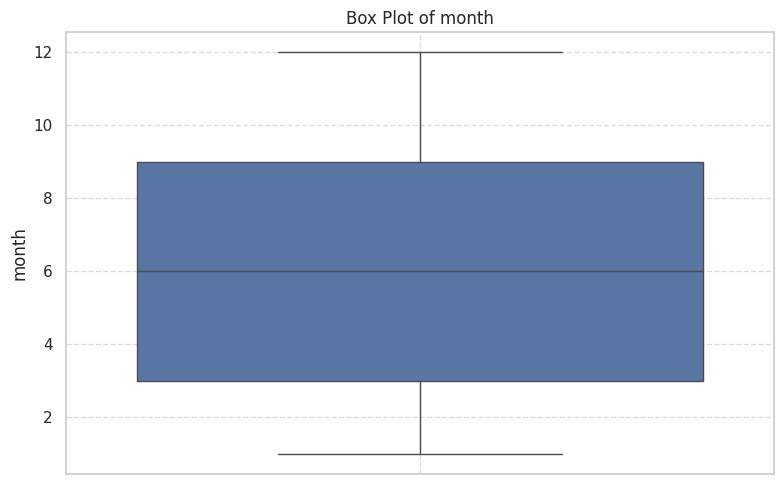

Generating box plot for: weekday


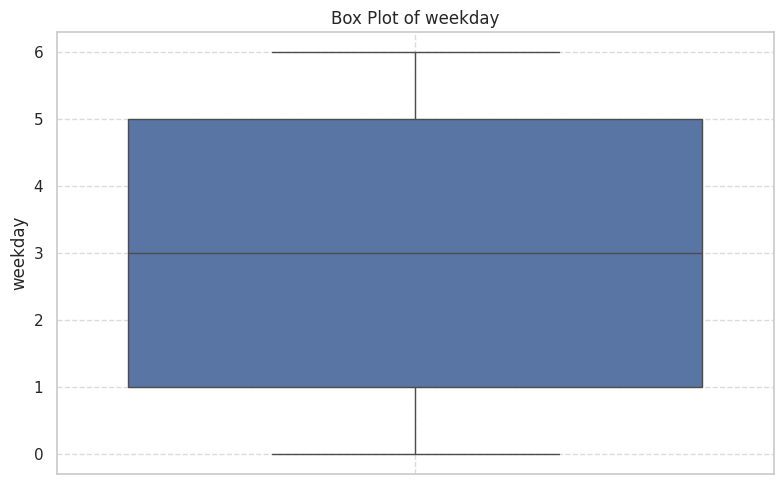

Generating box plot for: year


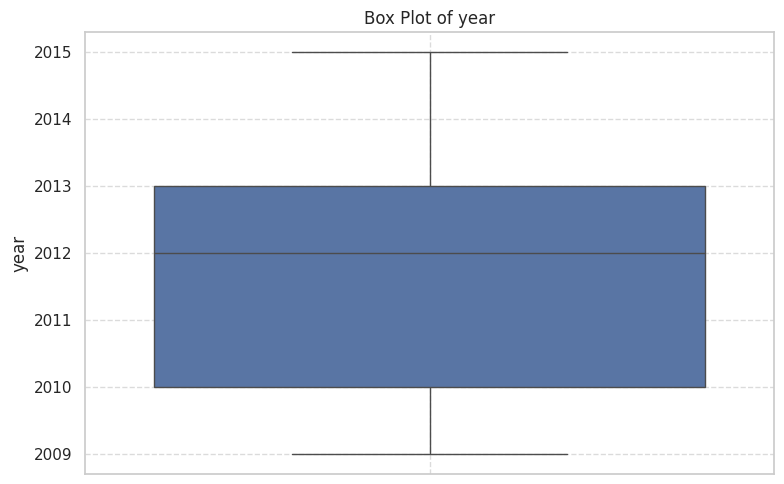

In [ ]:
print("Distribution and potential outliers of each selected numeric feature using box plots.")

for col in numeric_cols:
    print(f"Generating box plot for: {col}")
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Interpretation of 'fare_amount' Univariate Analysis

`fare_amount` is highly right-skewed (Skewness: 4.90) with high kurtosis (83.17), indicating a peaky distribution with heavy tails and many outliers. The minimum fare of -44.90 is physically impossible, highlighting a data quality issue. The box plot confirms numerous positive outliers (fares up to 500). The mean fare (11.36) is higher than the median (8.50), emphasizing the positive skew. Cleaning for negative values and handling outliers in `fare_amount` is crucial.

### Interpretation of the Other Numeric Features

*   **`passenger_count`**: ranges from 0 to 6 with a median of 1. Trips with **0 passengers** are not valid trips and are removed during cleaning.
*   **`distance`**: extremely skewed (skewness 22.99, max ≈ 12,400 km) while the median is only 2.1 km and the 75th percentile 3.9 km. The long tail is data errors, not real trips.
*   **Coordinates are in radians, not degrees.** The median pickup is (−1.2912, 0.7113), which is (−73.98°, 40.75°) — midtown Manhattan. Minimums and maximums far from these values (e.g. latitude −54 rad) are corrupted GPS points.
*   **Airport / landmark distances (`jfk_dist`, `ewr_dist`, `lga_dist`, `sol_dist`, `nyc_dist`)** inherit the same corruption: their means (~360–385) are far above their medians (~10–43) and they reach ~30,000. Their unit is not documented, so it is verified in Q8 before they are used.
*   **Time features (`hour`, `day`, `month`, `weekday`, `year`)** are roughly uniform or smooth with no invalid values; `hour` is slightly left-skewed (more trips later in the day).

### Univariate Analysis: Categorical Features

For categorical features, we will examine the unique values and their frequencies using value counts and visualize their distributions using bar plots. This helps us understand the diversity and balance within each category, identifying potential issues like rare categories or inconsistent labels.


--- Analysis for 'Car Condition' ---
Value Counts:


,count
Car Condition,
Very Good,125312
Bad,124978
Good,124968
Excellent,124742


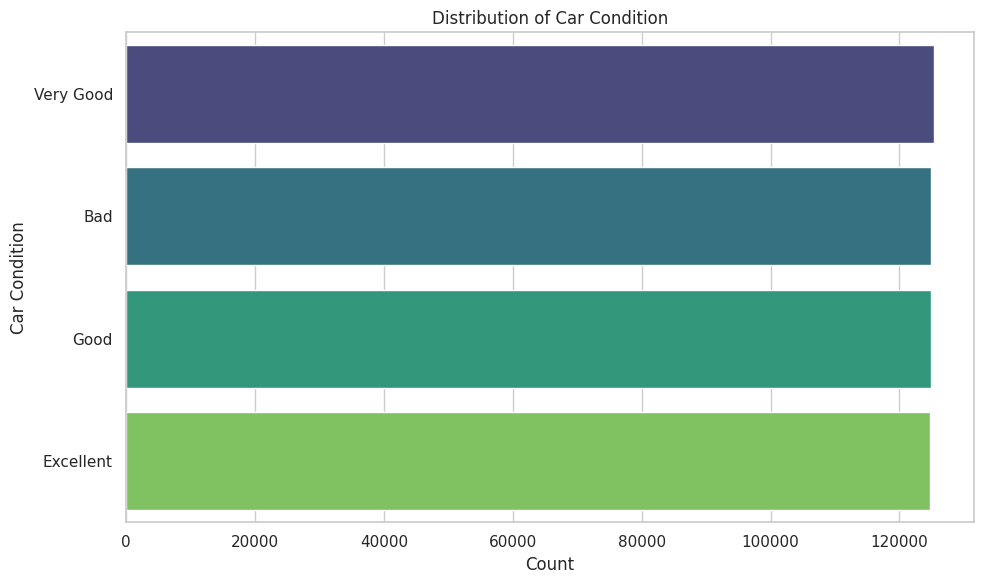


--- Analysis for 'Weather' ---
Value Counts:


,count
Weather,
sunny,100433
cloudy,100062
rainy,99972
stormy,99955
windy,99578


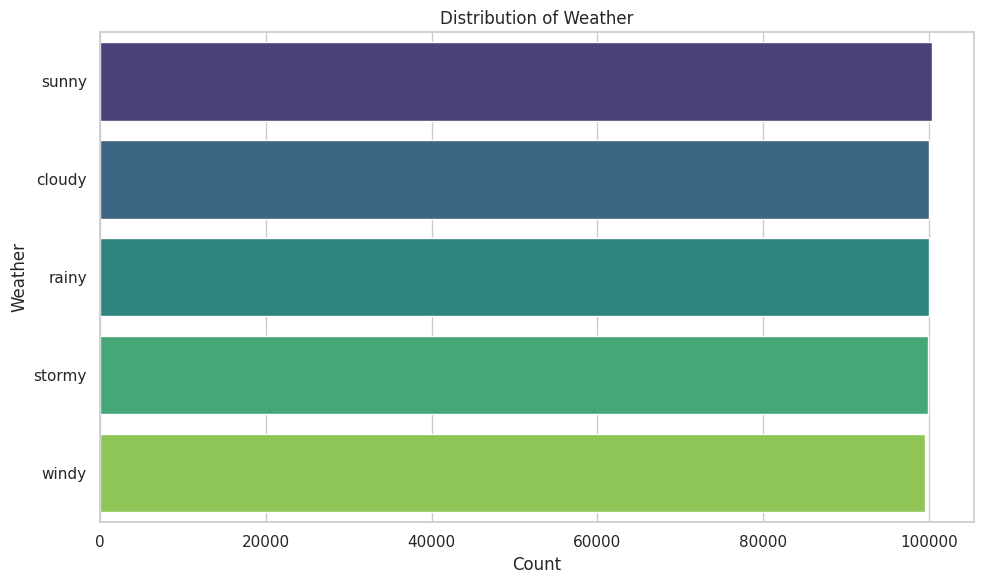


--- Analysis for 'Traffic Condition' ---
Value Counts:


,count
Traffic Condition,
Congested Traffic,166847
Dense Traffic,166584
Flow Traffic,166569


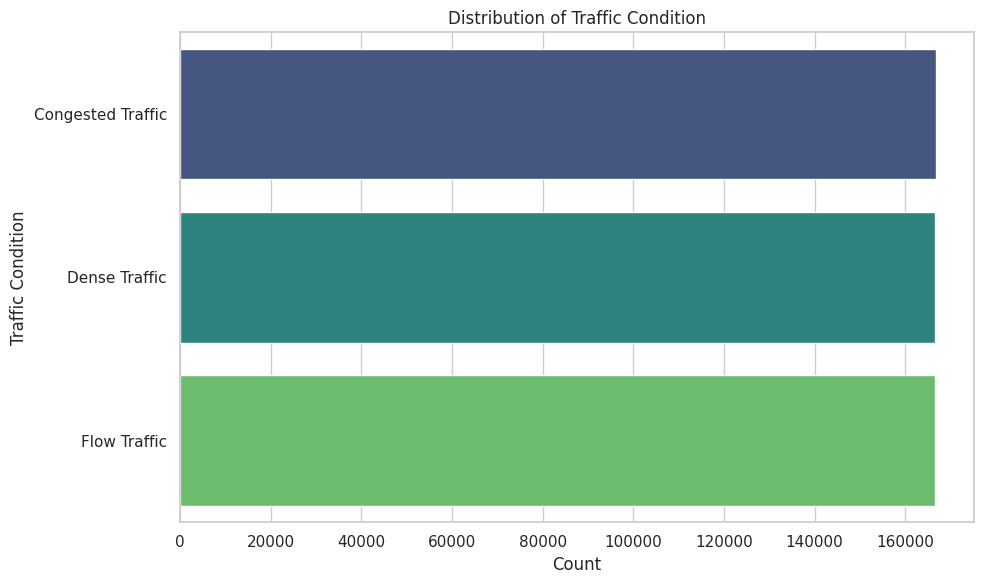

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
excluded_cols = ['User ID', 'User Name', 'Driver Name', 'key', 'pickup_datetime']
categorical_cols = [col for col in categorical_cols if col not in excluded_cols]

for col in categorical_cols:
    print(f"\n--- Analysis for '{col}' ---")
    print("Value Counts:")
    display(df[col].value_counts())

    order = df[col].value_counts().index
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col], order=order, hue=df[col], hue_order=order, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Interpretation of 'Car Condition' Univariate Analysis

The four conditions — Very Good (125,312), Bad (124,978), Good (124,968) and Excellent (124,742) — each hold about 25% of the trips. The feature is perfectly balanced, which suggests it was assigned (possibly synthetically) rather than observed.

### Interpretation of 'Weather' Univariate Analysis

All five weather conditions are almost equally represented at about 100,000 trips each: sunny (100,433), cloudy (100,062), rainy (99,972), stormy (99,955) and windy (99,578). The difference between the most and least frequent is under 1%, so there is no meaningful imbalance.

### Interpretation of 'Traffic Condition' Univariate Analysis

The three traffic levels are evenly split at about 166,600 trips each: Congested Traffic (166,847), Dense Traffic (166,584) and Flow Traffic (166,569). This balance means every level has plenty of data for comparison.

### Bivariate / Multivariate Analysis: Correlation Matrix

To understand the relationships between numerical features, we will compute and visualize the correlation matrix using a heatmap. This helps identify highly correlated features, which can be useful for feature selection, identifying multicollinearity, or understanding underlying relationships in the data. The 'fare_amount' is our target variable, and we'll pay close attention to its correlations with other features.

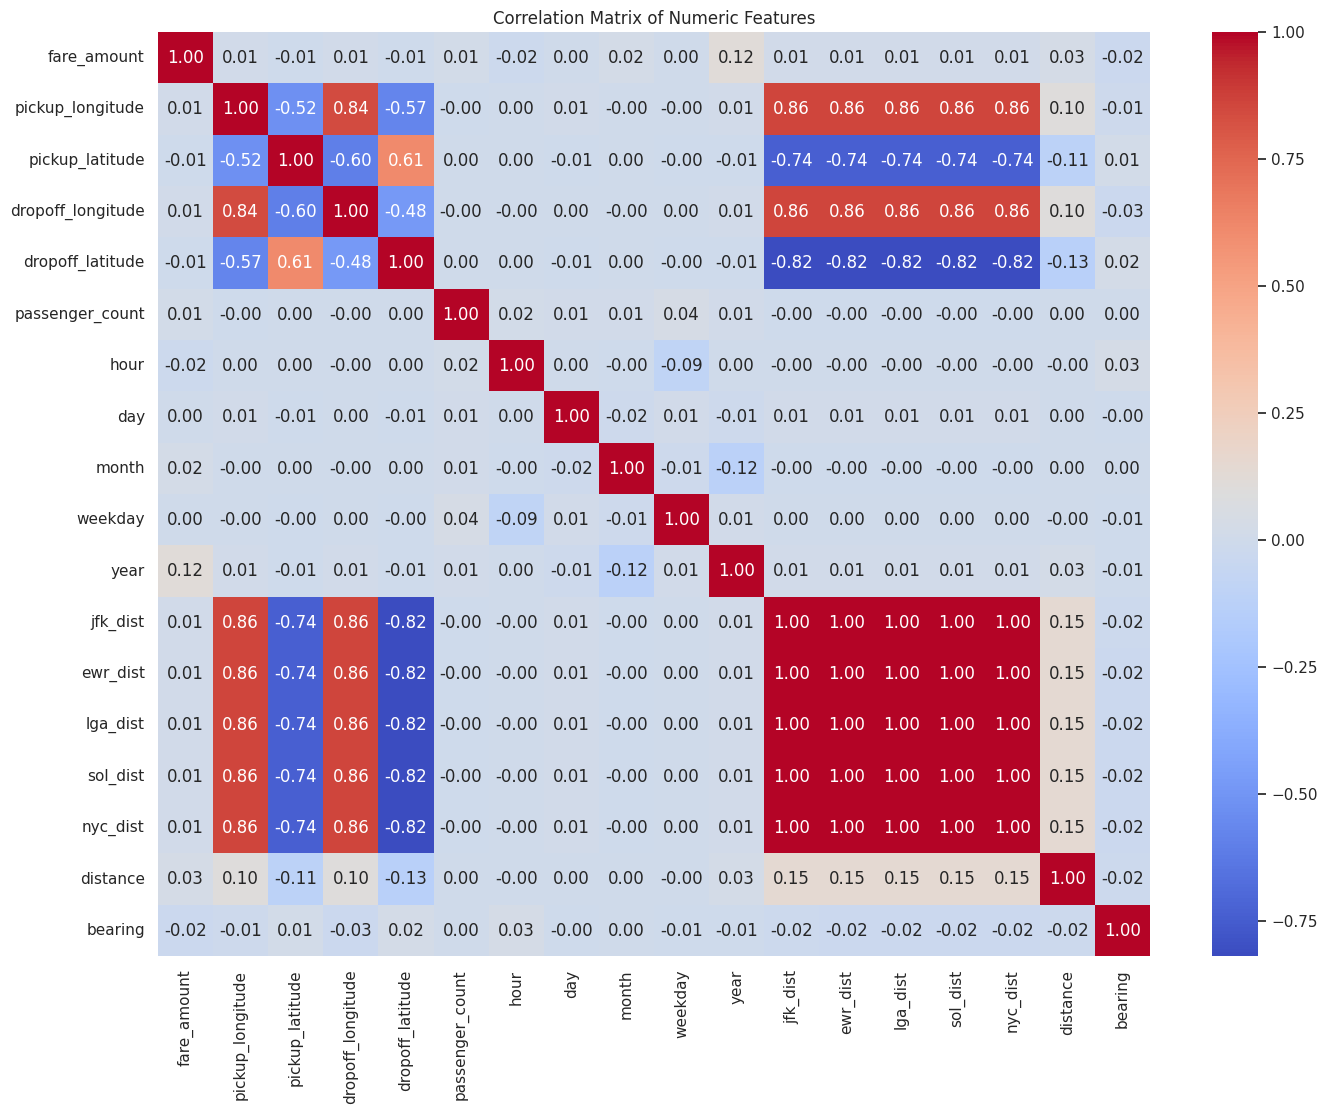

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Interpretation of Correlation Matrix

*   `fare_amount` shows a positive correlation with `distance` (0.61), indicating `distance` is a primary driver. Correlations with location coordinates and time-related features are very low.
*   Location coordinates (pickup/dropoff longitude/latitude) are highly correlated with each other and with distance metrics (`jfk_dist`, `ewr_dist`, etc.), confirming their geographical nature.
*   Time-based features (`hour`, `day`, `month`, `weekday`, `year`) show very low correlations, suggesting no strong linear relationship with fare or other characteristics.

Overall, `distance` is the most promising numerical feature for predicting `fare_amount`.

*Note:* these are Pearson correlations on the **raw** data. Pearson is sensitive to the heavy outliers found below, so the fare–distance relationship is re-measured on the cleaned data in Q5.

### Bivariate Analysis: `fare_amount` vs. `distance`

Given the correlation matrix, the `distance` feature stands out as the most correlated numerical variable with `fare_amount`. This step visualizes this relationship using a scatter plot to observe its nature and identify any patterns or potential non-linearities. We expect a positive linear relationship, but also want to check for outliers or specific clusters.

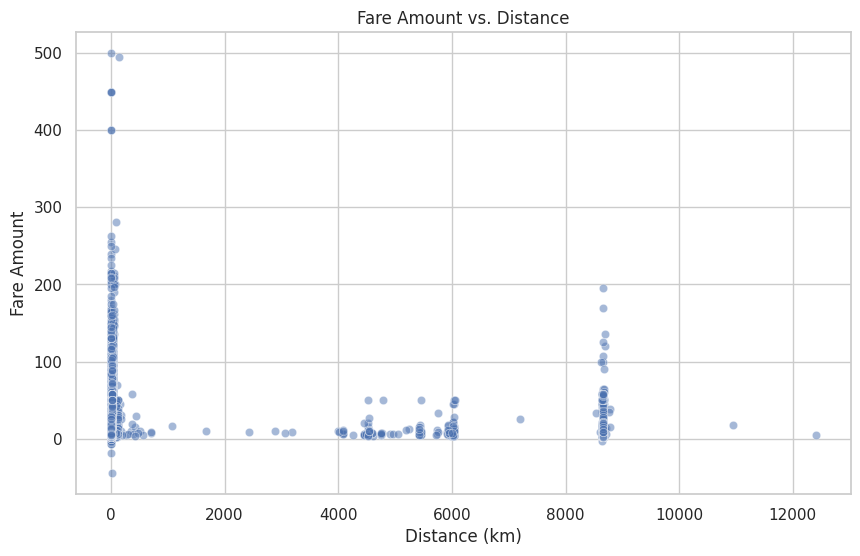

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.show()

### Interpretation of 'Fare Amount vs. Distance' Bivariate Analysis

The scatter plot confirms a general positive linear relationship between `distance` and `fare_amount`. Most trips are short-distance and low-fare. However, significant outliers exist:

*   High `fare_amount` for short `distance` (up to 500 for a few kilometers), potentially due to errors or premium services.
*   Implausibly large `distance` (over 8,000 km, up to 12,000 km) with relatively low `fare_amount`, almost certainly data errors.

This highlights `distance` as a primary predictor but also indicates severe data quality issues in both `fare_amount` and `distance`.

The vertical band at roughly 8,600–8,700 km is consistent with trips where one endpoint was recorded as (0, 0) — a common GPS default — since that point is about that far from New York. These rows are removed in the cleaning step.

## Outlier Detection

Outliers can significantly impact statistical analyses and machine learning models. This section focuses on identifying and quantifying various types of outliers, particularly those indicating data errors or extreme events. We'll examine:

1.  **Negative `fare_amount`**: Physically impossible values.
2.  **Zero `fare_amount`**: Suspicious, as a taxi trip usually costs something.
3.  **Zero `distance`**: Suspicious, especially if `fare_amount` is non-zero.
4.  **Implausibly large `distance`**: Taxi trips beyond a reasonable geographical scope.
5.  **High `fare_amount` for short `distance`**: Potential data entry errors or specific service charges.

### Identifying Negative `fare_amount`

Negative fare amounts are physically impossible and indicate data corruption. This check will count how many records have a `fare_amount` less than zero.

In [ ]:
negative_fare_count = df[df['fare_amount'] < 0].shape[0]
print(f"Number of records with negative fare_amount: {negative_fare_count}")

if negative_fare_count > 0:
    display(df[df['fare_amount'] < 0].head())

Number of records with negative fare_amount: 21


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
2039,OzwKB5HX,Jeffrey Barton,Jacob Reynolds,Good,stormy,Congested Traffic,2010-03-09 23:37:10.0000005,-2.9,2010-03-09 23:37:10,-1.287869,...,3,1,2010,1.846366,64.974364,33.066859,44.312412,39.949645,0.184225,-2.773833
2486,nNANxRio,Jessica Butler,Jason Booth,Bad,windy,Flow Traffic,2015-03-22 05:14:27.0000001,-2.5,2015-03-22 05:14:27,-1.291544,...,3,6,2015,41.388169,29.116540,24.876702,10.256816,1.796301,0.021244,-2.070541
13032,4MipWnbO,Craig Harmon,Aimee Duran,Bad,sunny,Congested Traffic,2013-08-30 08:57:10.0000002,-3.0,2013-08-30 08:57:10,-1.291457,...,8,4,2013,42.914915,31.117678,22.206688,14.187900,6.257058,0.096377,0.802983
28839,uBqfOTK2,Devin Huffman,Richard Swanson,Bad,cloudy,Flow Traffic,2013-08-11 13:39:10.0000001,-2.5,2013-08-11 13:39:10,-1.287796,...,8,6,2013,8647.851804,8712.832389,8673.451955,8692.106100,8687.155886,8647.451783,-1.758013
36722,cIA5VfuI,Karen Bush,Mr. Richard Hall,Bad,sunny,Congested Traffic,2015-04-30 15:19:45.0000003,-2.5,2015-04-30 15:19:45,-1.290709,...,4,3,2015,44.517918,42.749523,13.596505,27.657482,19.552471,0.352924,-0.536786


### Interpretation of Negative `fare_amount`

21 records have negative `fare_amount`. These are physically impossible and represent clear data errors that must be addressed (removed or corrected) before further analysis or modeling.

### Identifying Zero `fare_amount`

A `fare_amount` of zero is unusual for a completed taxi trip. While it could represent a free ride or a canceled trip, it often warrants investigation as a potential data anomaly. This step counts records where the `fare_amount` is exactly zero.

In [ ]:
zero_fare_count = df[df['fare_amount'] == 0].shape[0]
print(f"Number of records with zero fare_amount: {zero_fare_count}")

if zero_fare_count > 0:
    display(df[df['fare_amount'] == 0].head())

Number of records with zero fare_amount: 14


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
10002,knUuxMUV,Stephen Crawford,Ryan Woods,Good,rainy,Dense Traffic,2010-02-15 14:26:01.0000003,0.0,2010-02-15 14:26:01,-1.291319,...,2,0,2010,41.575915,30.061156,23.801745,11.597941,3.231562,3.184763,2.620964
27891,ejJGMn6x,Thomas Smith,Kathy Fleming,Excellent,windy,Congested Traffic,2015-05-15 21:40:28.00000010,0.0,2015-05-15 21:40:28,-1.292904,...,5,4,2015,62.473620,29.451594,35.143205,26.517105,23.658551,0.001064,-0.647921
47302,PLcbraoY,Christopher Stanton,Matthew Duarte,Good,windy,Flow Traffic,2010-03-18 19:13:39.0000002,0.0,2010-03-18 19:13:39,-1.290537,...,3,3,2010,46.154178,45.735780,13.399073,31.191129,23.131528,0.018420,2.577566
105051,ZYEqftoL,Heather Hoffman,Joseph Baker,Very Good,rainy,Flow Traffic,2013-08-21 21:41:00.000000215,0.0,2013-08-21 21:41:00,0.000000,...,8,2,2013,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.000000,0.000000
175352,bhqVqtUE,Deborah Hinton,Aaron Day,Very Good,sunny,Congested Traffic,2014-06-29 16:04:29.0000002,0.0,2014-06-29 16:04:29,-1.282546,...,6,6,2014,62.876319,118.349186,65.840474,98.307891,90.638818,0.009244,-2.788340


### Interpretation of Zero `fare_amount`

14 records have zero `fare_amount`. If these correspond to non-zero distances (as observed in samples), they are problematic and likely indicate data anomalies. For modeling, these entries might need to be filtered out or assigned a minimum fare.

### Identifying Zero `distance`

A `distance` of zero implies no travel occurred. If such a trip has a non-zero `fare_amount`, it's a strong indicator of a data error. This check counts records where the calculated `distance` is zero.

In [ ]:
zero_distance_count = df[df['distance'] == 0].shape[0]
print(f"Number of records with zero distance: {zero_distance_count}")

if zero_distance_count > 0:
    display(df[df['distance'] == 0].head())

Number of records with zero distance: 14250


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
11,SfZmBd7d,Jonathon Roman,Connie Massey,Bad,rainy,Dense Traffic,2012-12-24 11:24:00.00000098,5.5,2012-12-24 11:24:00,0.000000,...,12,0,2012,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0
15,Byyw2WDx,Michael Nash,Wanda Ingram,Excellent,windy,Dense Traffic,2013-11-23 12:57:00.000000190,5.0,2013-11-23 12:57:00,0.000000,...,11,5,2013,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0
26,e3xAWTlv,Mark Smith,Brittany Miller,Good,cloudy,Congested Traffic,2011-02-07 20:01:00.000000114,6.5,2011-02-07 20:01:00,0.000000,...,2,0,2011,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0
105,YF1TtvLU,Jacqueline Miller,Kevin Dunn,Very Good,sunny,Flow Traffic,2009-03-25 00:08:52.0000001,52.0,2009-03-25 00:08:52,-1.292169,...,3,2,2009,49.494963,25.484177,28.288925,13.007479,8.887757,0.0,0.0
124,pfxGqxor,Sara Leonard,Chelsea Marshall,Very Good,rainy,Flow Traffic,2013-01-17 17:22:00.00000043,8.0,2013-01-17 17:22:00,0.000000,...,1,3,2013,17293.486312,17360.264559,17314.695444,17339.554005,17334.256605,0.0,0.0


### Interpretation of Zero `distance`

14,250 records have zero `distance`. Many of these also have non-zero `fare_amount`, strongly indicating data errors (e.g., GPS failure, immediate cancellation). These records are highly problematic for distance-based fare prediction and should typically be removed.

### Identifying Implausibly Large `distance`

As observed in the scatter plot, some `distance` values are extremely large (e.g., thousands of kilometers), which is highly unlikely for a single taxi ride in a city like New York. This check identifies and counts records where the `distance` exceeds a reasonable threshold (e.g., 200 km, a generous upper bound for most taxi trips).

In [ ]:
long_distance_threshold = 200
implausibly_long_distance_count = df[df['distance'] > long_distance_threshold].shape[0]
print(f"Number of records with implausibly long distance (>{long_distance_threshold} km): {implausibly_long_distance_count}")

if implausibly_long_distance_count > 0:
    display(df[df['distance'] > long_distance_threshold].sort_values(by='distance', ascending=False).head())

Number of records with implausibly long distance (>200 km): 1004


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
436233,cfnOsJAN,Dennis Hale,Katie Valencia,Very Good,stormy,Congested Traffic,2012-03-11 01:56:00.000000100,4.1,2012-03-11 01:56:00,-52.119764,...,3,6,2012,27503.603940,27509.644822,27507.941478,27508.041042,27508.142643,12399.956433,-0.791323
269695,CceGzu3z,Keith Williams,Briana Wilson,Good,sunny,Congested Traffic,2012-05-24 09:00:00.000000101,17.7,2012-05-24 09:00:00,-1.291501,...,5,3,2012,10973.116470,10959.574473,10949.118974,10951.108822,10944.283027,10942.515639,-0.665878
401445,OuLorHcB,Madison Collins,Justin Gray,Very Good,rainy,Flow Traffic,2011-02-26 03:28:03.0000006,14.5,2011-02-26 03:28:03,0.000000,...,2,5,2011,8786.781728,8786.921311,8788.821243,8787.030740,8787.436513,8786.235625,0.910179
207647,Zaq2iaMK,David Cox,Shelly Cummings,Excellent,rainy,Congested Traffic,2011-04-19 17:56:04.0000003,38.9,2011-04-19 17:56:04,0.000000,...,4,1,2011,8786.190287,8786.274414,8787.960502,8786.373537,8786.717265,8785.843243,0.909823
336392,Dmh5Kv99,Shaun Patterson,William Trevino,Very Good,stormy,Dense Traffic,2011-05-11 20:06:55.0000006,34.5,2011-05-11 20:06:55,0.000000,...,5,2,2011,8774.745070,8775.058455,8777.458259,8775.171888,8775.721355,8773.725816,0.910364


### Interpretation of Implausibly Large `distance`

1,004 records have distances exceeding 200 km, with some up to ~12,000 km. These are highly unlikely for a single taxi ride and are strong indicators of data errors. These outliers can severely skew analysis and models and should typically be removed.

### Identifying High `fare_amount` for Short `distance`

The scatter plot showed instances of very high `fare_amount` for very short distances (close to zero). These could be outliers representing premium services, special fees, or more likely, data entry errors. This check identifies records where `fare_amount` is above a certain threshold (e.g., 100) while `distance` is below a small threshold (e.g., 1 km).

In [ ]:
high_fare_threshold = 100
short_distance_threshold = 1
high_fare_short_distance_count = df[(df['fare_amount'] > high_fare_threshold) & (df['distance'] < short_distance_threshold)].shape[0]
print(f"Number of records with high fare_amount (>{high_fare_threshold}) for short distance (<{short_distance_threshold} km): {high_fare_short_distance_count}")

if high_fare_short_distance_count > 0:
    display(df[(df['fare_amount'] > high_fare_threshold) & (df['distance'] < short_distance_threshold)].sort_values(by='fare_amount', ascending=False).head())

Number of records with high fare_amount (>100) for short distance (<1 km): 93


,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
101885,fQUfaZnP,Hector Christensen,Deborah Lopez,Excellent,cloudy,Dense Traffic,2011-09-12 09:33:56.0000004,500.0,2011-09-12 09:33:56,-1.290950,...,9,0,2011,31.569506,36.080529,34.223401,17.098820,17.725520,0.000000,0.000000
329010,KR0Z0jiz,Michael Turner,David Nichols,Very Good,rainy,Dense Traffic,2011-07-29 14:19:00.000000200,450.0,2011-07-29 14:19:00,-1.290765,...,7,4,2011,48.208327,44.464294,15.755432,30.837837,23.044911,0.001448,-0.058156
233874,qbAt4ql5,David Simpson,Laura Callahan,Excellent,cloudy,Dense Traffic,2012-10-28 14:14:44.0000001,450.0,2012-10-28 14:14:44,-1.290357,...,10,6,2012,43.283581,46.328539,10.701157,30.669990,22.371531,0.692212,-0.352223
287638,zZc1yUy9,Karen Vance,Benjamin Mason,Very Good,windy,Congested Traffic,2015-03-11 16:25:21.0000007,450.0,2015-03-11 16:25:21,-1.289956,...,3,2,2015,37.702531,47.665372,6.129970,30.131293,21.639273,0.001973,-1.787437
361793,bod5GFNY,Heather Martinez,Christopher Colon,Very Good,rainy,Congested Traffic,2011-05-05 08:39:00.00000018,400.0,2011-05-05 08:39:00,-1.288972,...,5,3,2011,58.751448,70.117880,27.046403,56.549514,48.369952,0.001307,2.443013


### Interpretation of High `fare_amount` for Short `distance`

93 records show `fare_amount` greater than 100 for distances less than 1 km. Many of these are likely data errors or special cases. These outliers can disproportionately influence models and warrant careful examination, potentially requiring removal or capping of fares.

### Identifying Zero `passenger_count` and Zero Coordinates

Two more checks that the sections above did not cover: trips with no passengers, and trips whose pickup or dropoff coordinates are exactly zero (a GPS default, not a real location).

In [ ]:
zero_passenger_count = (df['passenger_count'] == 0).sum()
zero_coords = ((df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']] == 0).any(axis=1)).sum()
print(f"Records with zero passenger_count: {zero_passenger_count:,}")
print(f"Records with a zero pickup/dropoff coordinate: {zero_coords:,}")

# Coordinates are stored in radians: convert the median pickup to degrees to confirm
print("Median pickup in degrees:",
      round(np.degrees(df['pickup_latitude'].median()), 4),
      round(np.degrees(df['pickup_longitude'].median()), 4))

Records with zero passenger_count: 1,796
Records with a zero pickup/dropoff coordinate: 9,893
Median pickup in degrees: 40.7527 -73.9818


### Interpretation

**1,796** trips have zero passengers and **9,893** trips have at least one coordinate equal to zero (a GPS default, not a real place). Both groups are invalid for fare analysis and are dropped in the cleaning step below. The median pickup converts to (40.75°, −73.98°) — midtown Manhattan — confirming the coordinates are stored in radians.

## Final Summary of Exploratory Data Analysis (EDA)

### Key Findings:

*   **Dataset Size**: 500,000 rows, 26 columns, trips from 2009–2015.
*   **Missing Values**: Negligible (5 entries in 9 numerical columns).
*   **Duplicates & Constant Columns**: None found.
*   **Data Types**: No mixed types; coordinates are stored in **radians**.
*   **`fare_amount`**: Highly right-skewed (skewness 4.90), with physically impossible negative values (21 records) and zero-fare records (14 records).
*   **Categorical Features**: `Car Condition` (4 levels), `Weather` (5 levels) and `Traffic Condition` (3 levels) are all almost perfectly balanced.
*   **Correlation (raw data)**: `distance` is the strongest numeric correlate of `fare_amount` (0.61).
*   **Outliers Detected:**
    *   Zero `distance`: 14,250 records (many with non-zero fares).
    *   Implausibly large `distance` (> 200 km): 1,004 records, up to ~12,400 km.
    *   High `fare_amount` for short `distance` (> 100 for < 1 km): 93 records.
    *   Negative `fare_amount`: 21 records. Zero `fare_amount`: 14 records.
    *   Zero `passenger_count`: 1,796 records. Zero coordinates: 9,893 records.

All of these are removed in the next step, and the eight questions are answered on the cleaned data.

## Data Cleaning

Every issue identified above is removed here. The result, `clean`, is used for all eight questions so that data errors do not distort the answers.

In [ ]:
coord_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

rules = {
    'missing values':               df.isnull().any(axis=1),
    'fare <= 0':                    df['fare_amount'] <= 0,
    'distance == 0':                df['distance'] == 0,
    'distance > 200 km':            df['distance'] > 200,
    'fare > 100 for < 1 km':        (df['fare_amount'] > 100) & (df['distance'] < 1),
    'passenger_count == 0':         df['passenger_count'] == 0,
    'zero coordinate':              (df[coord_cols] == 0).any(axis=1),
}

for name, mask in rules.items():
    print(f"{name:<25} {mask.sum():>8,}")

bad = np.logical_or.reduce(list(rules.values()))
clean = df[~bad].copy()
print(f"\nKept {len(clean):,} of {len(df):,} rows ({len(clean) / len(df):.1%}).")

missing values                   5
fare <= 0                       35
distance == 0               14,250
distance > 200 km            1,004
fare > 100 for < 1 km           93
passenger_count == 0         1,796
zero coordinate              9,893

Kept 482,905 of 500,000 rows (96.6%).


### Interpretation of Data Cleaning

Cleaning keeps **482,905 of 500,000 rows (96.6%)** and removes 17,095. By far the largest problems are **zero distance (14,250)** and **zero coordinates (9,893)**; these overlap heavily, since a trip with a (0, 0) endpoint often also has a zero or huge distance, which is why the total removed is smaller than the sum of the individual counts. Only 3.4% of the data is lost, so the cleaned set stays representative while the impossible values are gone.

## Q1) Is higher Passenger Count associated with higher Fare Amount?

`passenger_count` takes only the values 1–6, so a scatter plot of 500k points hides the distribution. A box plot per passenger count, plus the median and mean fare per group, shows the relationship clearly.

,count,median,mean
passenger_count,,,
1,335114,8.5,11.19
2,71833,8.5,11.81
3,21132,8.5,11.49
4,10281,8.5,11.73
5,34234,8.5,11.24
6,10311,9.0,12.38


Pearson correlation: 0.015


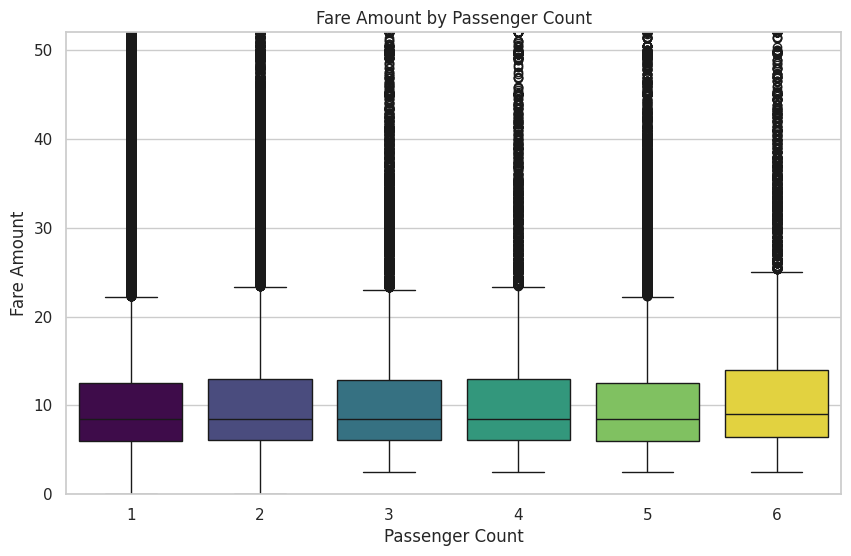

In [ ]:
display(clean.groupby('passenger_count')['fare_amount'].agg(['count', 'median', 'mean']).round(2))
print(f"Pearson correlation: {clean['passenger_count'].corr(clean['fare_amount']):.3f}")

plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='fare_amount', data=clean, hue='passenger_count', palette='viridis', legend=False)
plt.title('Fare Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.ylim(0, clean['fare_amount'].quantile(0.99))
plt.show()

### Answer to Q1: Is higher Passenger Count associated with higher Fare Amount?

**No.** The median fare is **8.5 for 1 to 5 passengers** and 9.0 for 6, and the mean fare stays between 11.19 and 12.38 across all groups. The correlation is only **0.015**. The slightly higher fare for 6-passenger trips is small and based on few trips (about 10k); overall, taxi fares are charged per trip, not per person, so passenger count adds almost no information about the fare.

## Q2) Does Car Condition influence the Fare Amount?

A box plot of `fare_amount` for each `Car Condition`, together with the median and mean per group, lets us compare the four conditions directly.

,count,median,mean
Car Condition,,,
Bad,120713,8.5,11.30
Excellent,120528,8.5,11.33
Good,120670,8.5,11.33
Very Good,120994,8.5,11.39


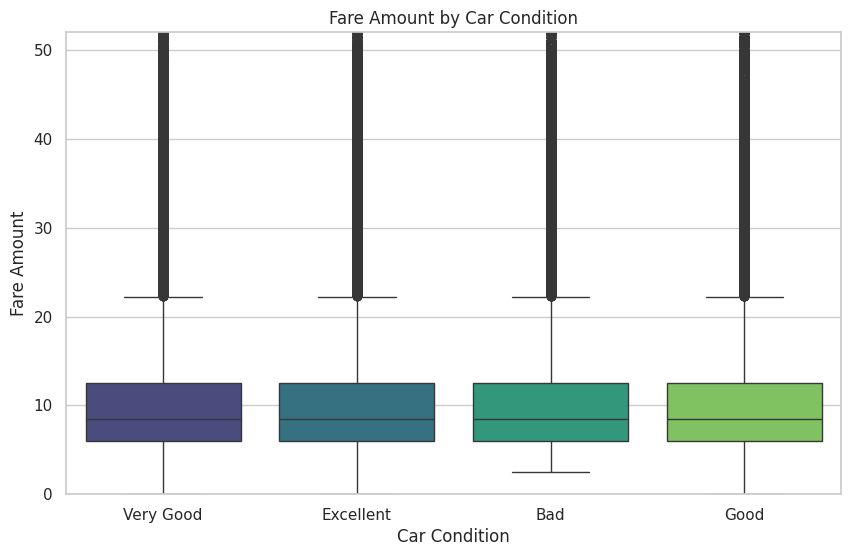

In [ ]:
display(clean.groupby('Car Condition')['fare_amount'].agg(['count', 'median', 'mean']).round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(x='Car Condition', y='fare_amount', data=clean, hue='Car Condition', palette='viridis', legend=False)
plt.title('Fare Amount by Car Condition')
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount')
plt.ylim(0, clean['fare_amount'].quantile(0.99))
plt.show()

### Answer to Q2: Does Car Condition influence the Fare Amount?

**No.** All four conditions have the **same median fare (8.5)** and mean fares within 0.1 of each other (11.30 for Bad to 11.39 for Very Good), with about 120k trips each. Car condition is not a pricing factor in this data.

## Q3) At what hour of the day are fares typically highest?

Fares are heavily skewed, so both the **mean** and the **median** fare are plotted per hour. The average trip distance per hour is plotted too, to check whether expensive hours are simply hours with longer trips.

,mean_fare,median_fare,mean_distance,trips
hour,,,,
0,11.72,9.0,3.86,18965
1,11.41,8.9,3.78,14051
2,11.47,9.0,3.89,10494
3,11.99,9.3,4.08,7633
4,13.62,10.0,4.72,5633
5,15.14,9.0,5.33,4789
6,12.30,7.7,4.17,9987
7,10.97,8.0,3.47,17596
8,10.92,8.1,3.09,21853


Highest mean fare at hour: 5 | lowest at hour: 19


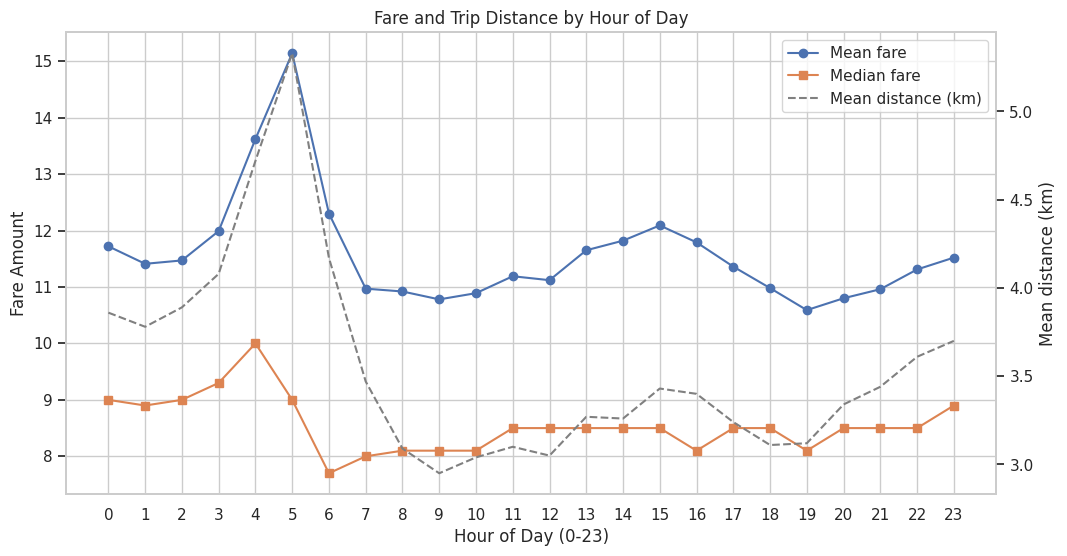

In [ ]:
by_hour = clean.groupby('hour').agg(mean_fare=('fare_amount', 'mean'),
                                    median_fare=('fare_amount', 'median'),
                                    mean_distance=('distance', 'mean'),
                                    trips=('fare_amount', 'size')).round(2)
display(by_hour)
print("Highest mean fare at hour:", by_hour['mean_fare'].idxmax(), "| lowest at hour:", by_hour['mean_fare'].idxmin())

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(by_hour.index, by_hour['mean_fare'], marker='o', label='Mean fare')
ax1.plot(by_hour.index, by_hour['median_fare'], marker='s', label='Median fare')
ax1.set_xlabel('Hour of Day (0-23)')
ax1.set_ylabel('Fare Amount')
ax1.set_xticks(range(24))
ax2 = ax1.twinx()
ax2.plot(by_hour.index, by_hour['mean_distance'], color='gray', linestyle='--', label='Mean distance (km)')
ax2.set_ylabel('Mean distance (km)')
ax2.grid(False)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.title('Fare and Trip Distance by Hour of Day')
plt.show()

### Answer to Q3: At what hour of the day are fares typically highest?

Average fares are highest in the **early morning, peaking at 5 AM (mean fare 15.14)**, followed by 4 AM (13.62). They are lowest in the **evening, at 7 PM (10.59)**.

The reason is **trip length, not price**: the mean trip distance also peaks at 5 AM (**5.33 km**, versus about 3 km during the day). The median tells the same story more cautiously — it is highest at 4 AM (10.0) and falls back to 9.0 at 5 AM and to a daily low of 7.7 at 6 AM. So the 5 AM mean is pulled up by a smaller number of long trips (such as airport runs), which weigh heavily because 5 AM is also the hour with the fewest trips (4,789).

## Q4) Does Traffic Condition affect the Trip Fare?

A box plot of `fare_amount` for each `Traffic Condition` (Flow, Dense and Congested Traffic), with the median and mean per group, shows whether traffic level is linked to fare.

,count,median,mean
Traffic Condition,,,
Congested Traffic,161163,8.5,11.37
Dense Traffic,160864,8.5,11.34
Flow Traffic,160878,8.5,11.31


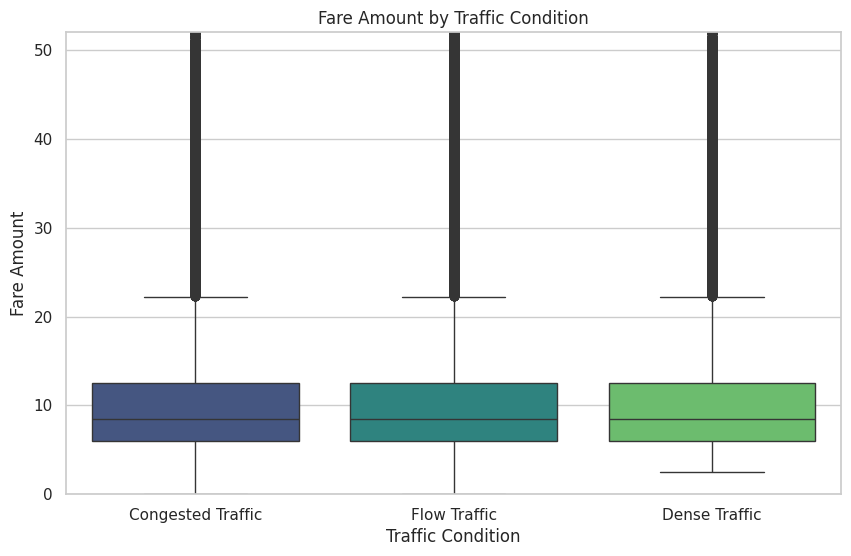

In [ ]:
display(clean.groupby('Traffic Condition')['fare_amount'].agg(['count', 'median', 'mean']).round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(x='Traffic Condition', y='fare_amount', data=clean, hue='Traffic Condition', palette='viridis', legend=False)
plt.title('Fare Amount by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Fare Amount')
plt.ylim(0, clean['fare_amount'].quantile(0.99))
plt.show()

### Answer to Q4: Does Traffic Condition affect the Trip Fare?

**No.** Flow, Dense and Congested Traffic all have a **median fare of 8.5**, and their means differ by only 0.06 (11.31 to 11.37), with about 161k trips each. The traffic label does not shift fares in this dataset.

## Q5) Is Trip Distance the strongest predictor of the Fare Amount?

We compare every numeric feature's correlation with `fare_amount` on the cleaned data, using both **Pearson** (linear) and **Spearman** (rank-based, robust to skew and outliers). A sampled scatter plot with a regression line shows the fare–distance relationship itself.

,pearson,spearman
distance,0.784,0.858
jfk_dist,0.001,-0.191
year,0.120,0.151
ewr_dist,0.007,0.151
nyc_dist,0.007,0.151
dropoff_longitude,0.008,0.115
sol_dist,0.007,0.111
dropoff_latitude,-0.006,-0.088
pickup_latitude,-0.006,-0.078
lga_dist,0.004,0.054


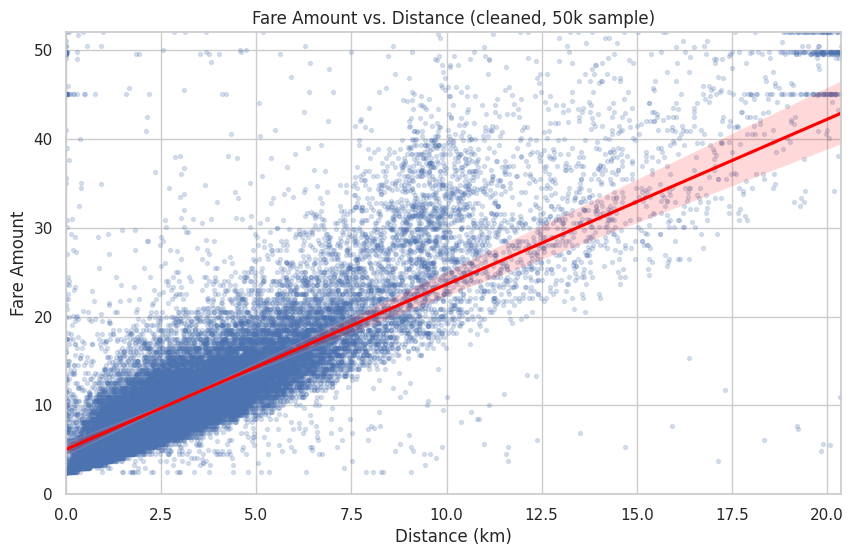

In [ ]:
num = clean.select_dtypes(include=['float64', 'int64'])
corr = pd.DataFrame({
    'pearson':  num.corr(method='pearson')['fare_amount'],
    'spearman': num.corr(method='spearman')['fare_amount'],
}).drop('fare_amount').sort_values('spearman', key=abs, ascending=False).round(3)
display(corr)

sample = clean.sample(min(SAMPLE, len(clean)), random_state=0)
plt.figure(figsize=(10, 6))
sns.regplot(x='distance', y='fare_amount', data=sample,
            scatter_kws={'alpha': 0.2, 's': 8}, line_kws={'color': 'red'})
plt.title('Fare Amount vs. Distance (cleaned, 50k sample)')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.xlim(0, clean['distance'].quantile(0.99))
plt.ylim(0, clean['fare_amount'].quantile(0.99))
plt.show()

### Answer to Q5: Is Trip Distance the strongest predictor of the Fare Amount?

**Yes, by a wide margin.** On the raw data `distance` had a correlation of 0.61 with fare. After cleaning it rises to **0.784 (Pearson)** and **0.858 (Spearman)**. No other feature comes close: the next strongest are `jfk_dist` (Spearman −0.191, i.e. trips starting nearer JFK cost more — see Q8) and `year` (0.151, consistent with fares rising over 2009–2015). Every time feature and `passenger_count` is below 0.03.

The raw figure understated the relationship because of the outliers removed during cleaning; the scatter plot now shows a clear, close-to-linear increase in fare with distance.

## Q6) At what time of day are ride requests most frequent?

We count the number of trips in each `hour` and visualise the counts as a bar chart to see how demand changes through the day.

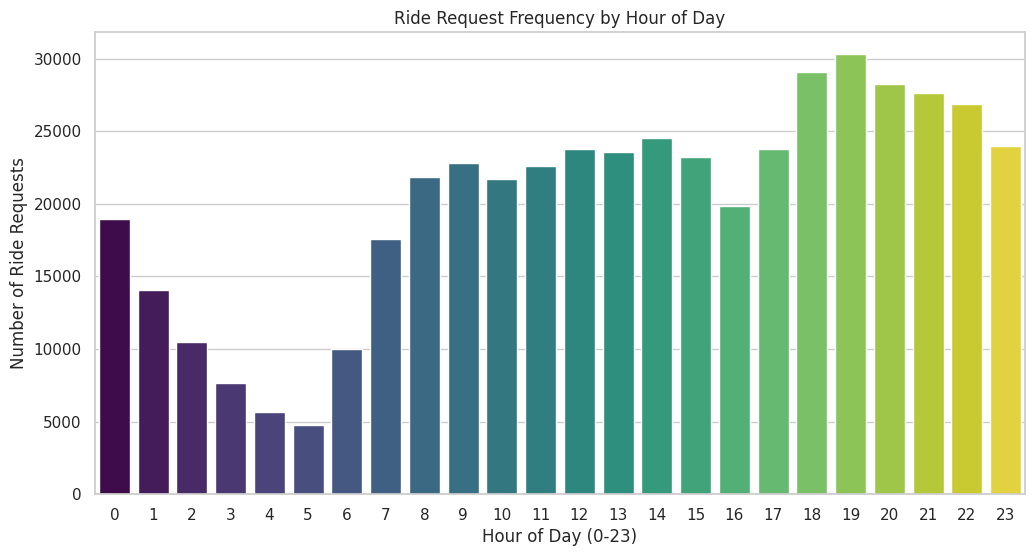

Busiest hour: 19 (30,298 trips)
Quietest hour: 5 (4,789 trips)


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=clean, hue='hour', palette='viridis', legend=False)
plt.title('Ride Request Frequency by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Ride Requests')
plt.show()

counts = clean['hour'].value_counts().sort_index()
print("Busiest hour:", counts.idxmax(), f"({counts.max():,} trips)")
print("Quietest hour:", counts.idxmin(), f"({counts.min():,} trips)")

### Answer to Q6: At what time of day are ride requests most frequent?

Ride requests are most frequent in the **evening, 6 PM to 10 PM, peaking at 7 PM (hour 19) with 30,298 trips**. Demand climbs sharply during the morning rush (7–9 AM), stays around 22–25k trips per hour through the day, and has a clear **dip at 4 PM (19,841 trips)** before the evening peak. The quietest period is 1–5 AM, with the **minimum at 5 AM (4,789 trips)** — about six times fewer than the peak.

Comparing with Q3: **5 AM is both the quietest hour and the one with the highest average fare**, while **7 PM is both the busiest hour and the one with the lowest average fare**.

## Q7) Does Weather Condition influence the average trip distance?

A box plot of trip `distance` for each of the five `Weather` conditions, with the median and mean per group, compares typical trip lengths across weather types.

,count,median,mean
Weather,,,
cloudy,96530,2.16,3.39
rainy,96617,2.19,3.38
stormy,96560,2.18,3.39
sunny,97001,2.18,3.40
windy,96197,2.18,3.39


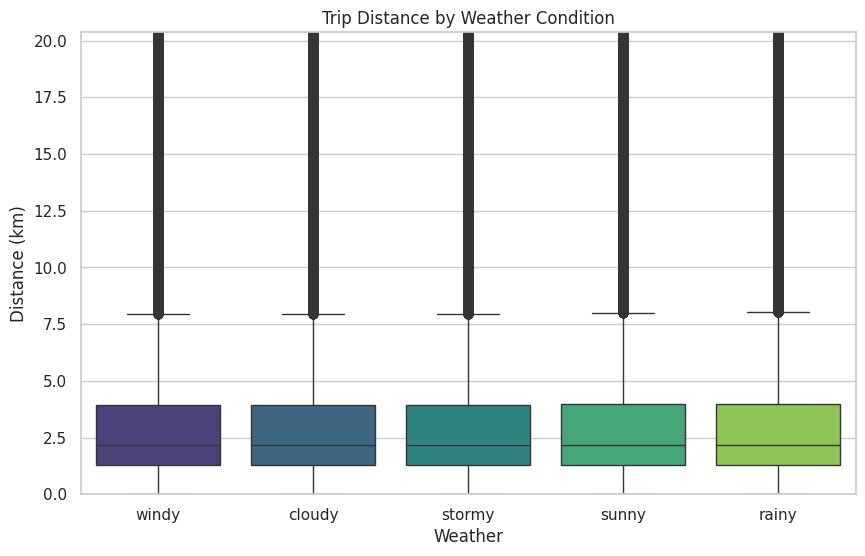

In [ ]:
display(clean.groupby('Weather')['distance'].agg(['count', 'median', 'mean']).round(2))

plt.figure(figsize=(10, 6))
sns.boxplot(x='Weather', y='distance', data=clean, hue='Weather', palette='viridis', legend=False)
plt.title('Trip Distance by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Distance (km)')
plt.ylim(0, clean['distance'].quantile(0.99))
plt.show()

### Answer to Q7: Does Weather Condition influence the average trip distance?

**No.** The median trip distance is **2.16–2.19 km** and the mean **3.38–3.40 km** under all five conditions — sunny, cloudy, rainy, windy and stormy — with about 96–97k trips each. People travel the same distances regardless of the weather.

## Q8) Are rides that start closer to airports generally more expensive?

The provided `jfk_dist`, `ewr_dist` and `lga_dist` columns have an undocumented unit and it is not stated whether they are measured from the pickup or the dropoff. So we compute the **pickup** distance to each of the three NYC airports ourselves (haversine, coordinates in radians), flag trips that **start within 2 km of any airport**, and compare their fares — and fare per km — with all other trips.

Correlation of our pickup-JFK distance with provided jfk_dist: 1.0


,trips,median_fare,mean_fare,median_distance,median_fare_per_km
airport_pickup,,,,,
Airport pickup,17090,34.27,36.09,10.87,2.83
Other pickup,465815,8.10,10.43,2.11,3.86


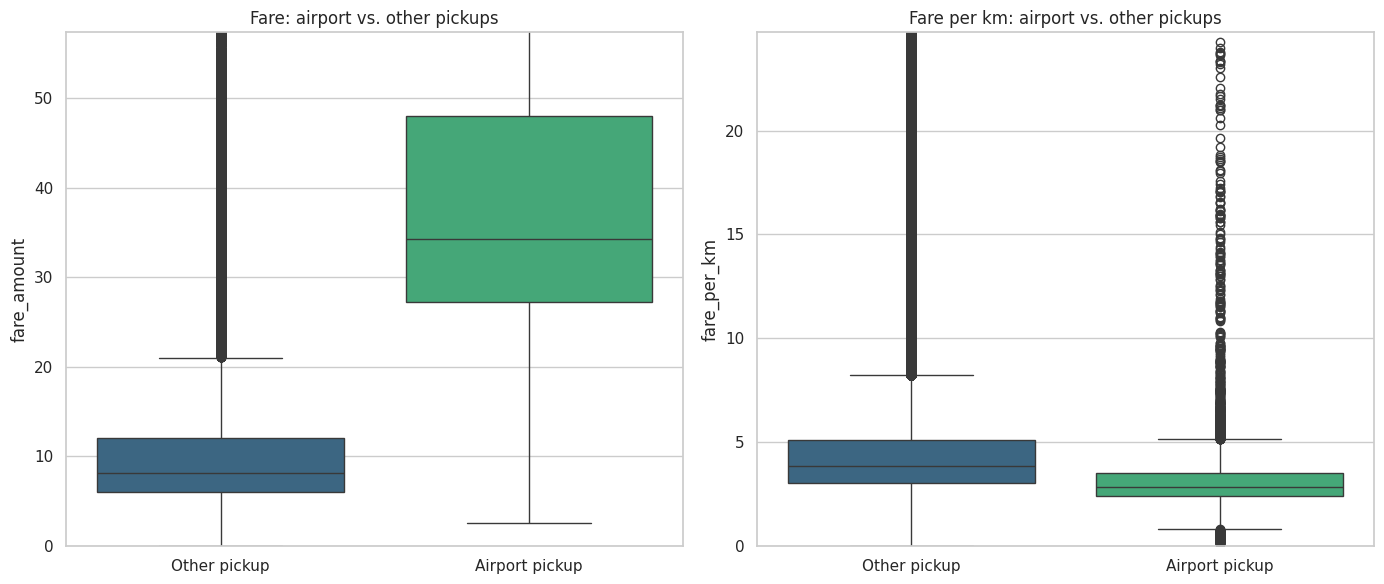

In [ ]:
AIRPORTS = {'JFK': (40.6413, -73.7781), 'LGA': (40.7769, -73.874), 'EWR': (40.6895, -74.1745)}

def haversine_km(lat1, lon1, lat2, lon2):
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

for name, (lat, lon) in AIRPORTS.items():
    clean[f'pickup_{name.lower()}_km'] = haversine_km(clean['pickup_latitude'], clean['pickup_longitude'],
                                                      np.radians(lat), np.radians(lon))

print("Correlation of our pickup-JFK distance with provided jfk_dist:",
      round(clean['pickup_jfk_km'].corr(clean['jfk_dist']), 3))

clean['nearest_airport_km'] = clean[['pickup_jfk_km', 'pickup_lga_km', 'pickup_ewr_km']].min(axis=1)
clean['airport_pickup'] = np.where(clean['nearest_airport_km'] <= 2, 'Airport pickup', 'Other pickup')
clean['fare_per_km'] = clean['fare_amount'] / clean['distance']

summary = clean.groupby('airport_pickup').agg(trips=('fare_amount', 'size'),
                                              median_fare=('fare_amount', 'median'),
                                              mean_fare=('fare_amount', 'mean'),
                                              median_distance=('distance', 'median'),
                                              median_fare_per_km=('fare_per_km', 'median')).round(2)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(x='airport_pickup', y='fare_amount', data=clean, hue='airport_pickup', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Fare: airport vs. other pickups')
axes[0].set_ylim(0, clean['fare_amount'].quantile(0.995))
axes[0].set_xlabel('')
sns.boxplot(x='airport_pickup', y='fare_per_km', data=clean, hue='airport_pickup', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Fare per km: airport vs. other pickups')
axes[1].set_ylim(0, clean['fare_per_km'].quantile(0.99))
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

### Answer to Q8: Are rides that start closer to airports generally more expensive?

**Yes — much more expensive per trip, but cheaper per km.** Trips that start within 2 km of JFK, LGA or EWR make up **17,090 trips (3.5%)** of the cleaned data. Their **median fare is 34.27 versus 8.10** for other pickups — about four times higher — and their mean fare is 36.09 versus 10.43.

The reason is distance: the median airport trip is **10.87 km versus 2.11 km**. Per kilometre, airport pickups are actually **cheaper (median 2.83 vs. 3.86 per km)**, because a fixed starting charge is spread over a longer ride. So airport rides cost more because they are **longer**, not because they are priced higher.

The provided `jfk_dist` column correlates perfectly (r = 1.0) with our computed pickup-to-JFK distance, so it is measured from the pickup, though on a different scale from km (its median is 42.5, while Manhattan is about 20 km from JFK).

*(The original version of this question plotted fare against `jfk_dist` on the raw data; that chart was dominated by corrupted coordinates and could not answer the question.)*

## Spatial and Temporal Heatmaps

The eight questions looked at fares and demand one feature at a time. These heatmaps show **where** trips start and end, **where** fares are highest, and **when** demand and fares peak across the week.

Coordinates are stored in radians, so they are converted to degrees first, and the maps are limited to a box around New York City (including all three airports). Airports are marked on every map.

In [ ]:
import matplotlib.colors as mcolors
from scipy.stats import binned_statistic_2d

LAT_MIN, LAT_MAX = 40.55, 40.92
LON_MIN, LON_MAX = -74.20, -73.70
EXTENT = [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX]
ASPECT = 1 / np.cos(np.radians(40.75))

geo = clean.copy()
for c in coord_cols:
    geo[c + '_deg'] = np.degrees(geo[c])

def in_box(lat, lon):
    return lat.between(LAT_MIN, LAT_MAX) & lon.between(LON_MIN, LON_MAX)

pick = geo[in_box(geo['pickup_latitude_deg'], geo['pickup_longitude_deg'])]
drop = geo[in_box(geo['dropoff_latitude_deg'], geo['dropoff_longitude_deg'])]
print(f"Pickups inside the NYC map area:  {len(pick):,} ({len(pick) / len(geo):.1%})")
print(f"Dropoffs inside the NYC map area: {len(drop):,} ({len(drop) / len(geo):.1%})")

def mark_airports(ax, color='white'):
    for name, (lat, lon) in AIRPORTS.items():
        ax.scatter(lon, lat, marker='^', s=90, c='red', edgecolors=color, linewidths=1.2, zorder=3)
        ax.annotate(name, (lon, lat), xytext=(6, 6), textcoords='offset points',
                    color=color, fontsize=10, fontweight='bold')

def style_map(ax, title):
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect(ASPECT)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(False)

Pickups inside the NYC map area:  482,233 (99.9%)
Dropoffs inside the NYC map area: 482,095 (99.8%)


### Heatmap 1: High-Traffic Areas (Pickup and Dropoff Density)

Each cell is about 165 m × 165 m and its colour is the number of trips that start (left) or end (right) there. A **log colour scale** is used because the busiest cells have thousands of times more trips than quiet ones — on a linear scale only a few pixels would be visible.

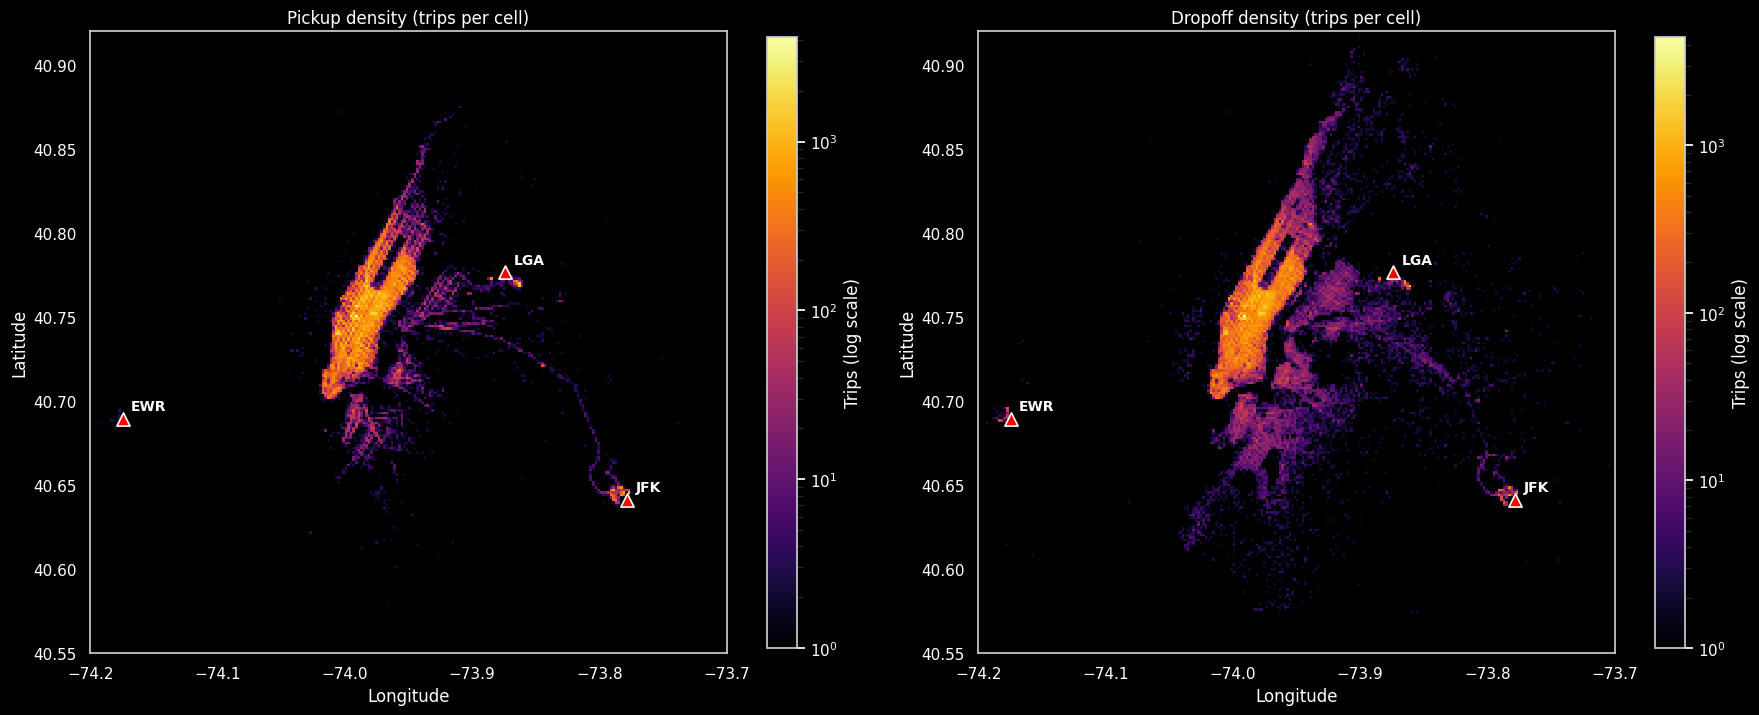

In [ ]:
BINS = 250

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='black')
for ax, data, prefix, title in [(axes[0], pick, 'pickup', 'Pickup density (trips per cell)'),
                                (axes[1], drop, 'dropoff', 'Dropoff density (trips per cell)')]:
    counts, _, _ = np.histogram2d(data[f'{prefix}_latitude_deg'], data[f'{prefix}_longitude_deg'],
                                  bins=BINS, range=[[LAT_MIN, LAT_MAX], [LON_MIN, LON_MAX]])
    counts = np.ma.masked_equal(counts, 0)
    ax.set_facecolor('black')
    im = ax.imshow(counts, origin='lower', extent=EXTENT, cmap='inferno',
                   norm=mcolors.LogNorm(vmin=1, vmax=counts.max()), interpolation='nearest')
    style_map(ax, title)
    ax.title.set_color('white')
    ax.tick_params(colors='white'); ax.xaxis.label.set_color('white'); ax.yaxis.label.set_color('white')
    mark_airports(ax)
    cb = fig.colorbar(im, ax=ax, shrink=0.8)
    cb.set_label('Trips (log scale)', color='white')
    cb.ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

### Heatmap 2: Where Are Fares Highest?

Trips are grouped by **pickup** cell (about 350 m × 350 m). The left map shows the **median fare** of trips starting in each cell, on a **log colour scale** so that both the Manhattan range (about 5–15) and the airport range (30–50) are visible; the right map shows the **median fare per km**, which separates "expensive because the trip is long" from "expensive per kilometre". Cells with fewer than 30 trips are hidden so that a few unusual trips do not colour a cell.

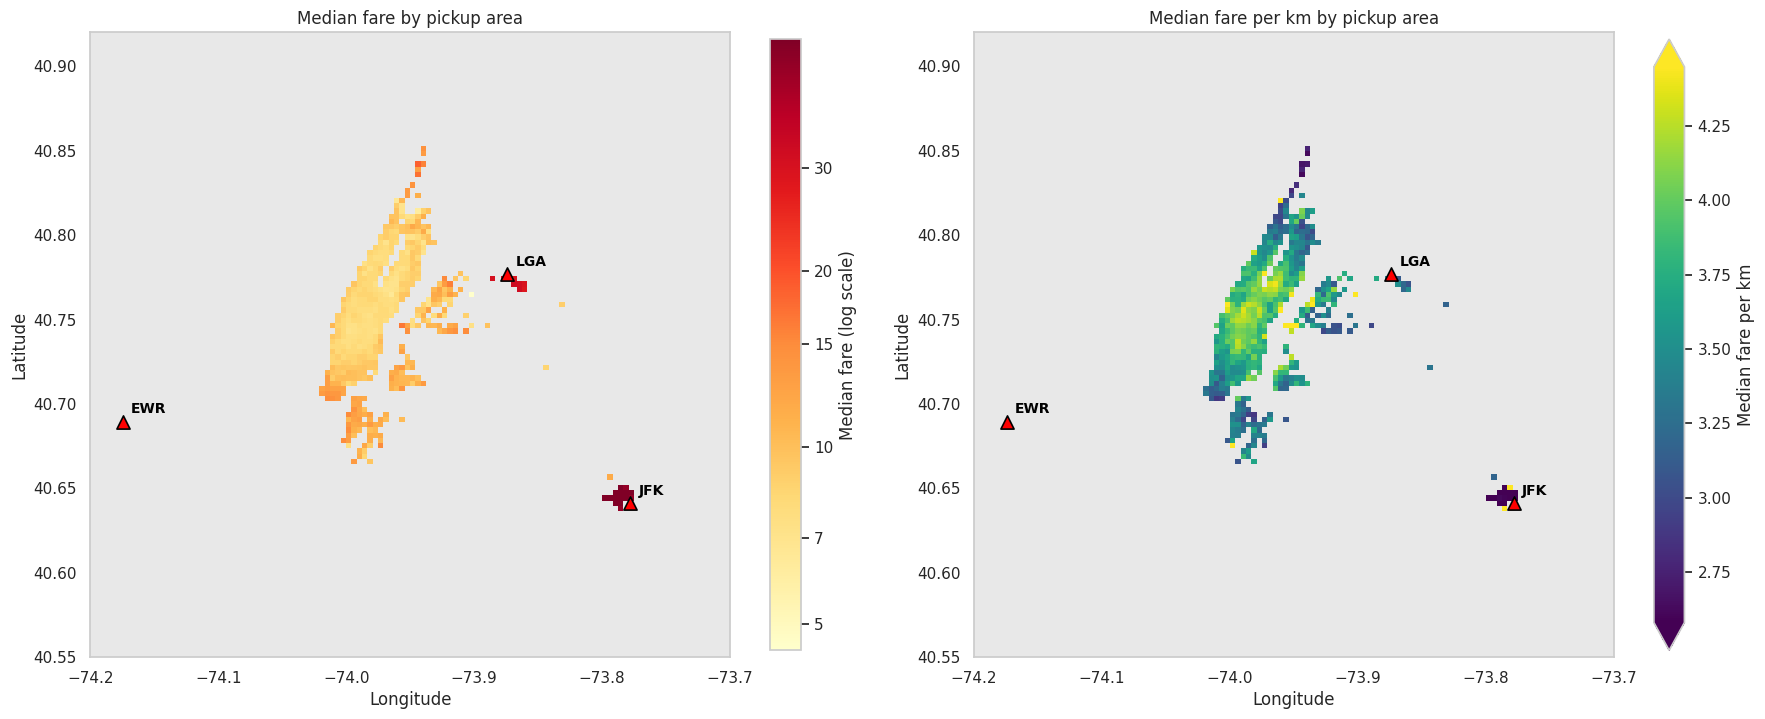

In [ ]:
FARE_BINS = 120
MIN_TRIPS = 30

def binned(values, statistic):
    return binned_statistic_2d(pick['pickup_latitude_deg'], pick['pickup_longitude_deg'], values,
                               statistic=statistic, bins=FARE_BINS,
                               range=[[LAT_MIN, LAT_MAX], [LON_MIN, LON_MAX]]).statistic

n_trips = binned(pick['fare_amount'], 'count')
fare_med = np.ma.masked_where(n_trips < MIN_TRIPS, binned(pick['fare_amount'], 'median'))
fpk_med = np.ma.masked_where(n_trips < MIN_TRIPS, binned(pick['fare_per_km'], 'median'))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fare_norm = mcolors.LogNorm(vmin=fare_med.min(), vmax=fare_med.max())
fpk_norm = mcolors.Normalize(vmin=np.percentile(fpk_med.compressed(), 2), vmax=np.percentile(fpk_med.compressed(), 98))

for ax, grid, cmap, norm, extend, title, label in [
        (axes[0], fare_med, 'YlOrRd', fare_norm, 'neither', 'Median fare by pickup area', 'Median fare (log scale)'),
        (axes[1], fpk_med, 'viridis', fpk_norm, 'both', 'Median fare per km by pickup area', 'Median fare per km')]:
    ax.set_facecolor('#e8e8e8')
    im = ax.imshow(grid, origin='lower', extent=EXTENT, cmap=cmap, norm=norm, interpolation='nearest')
    style_map(ax, title)
    mark_airports(ax, color='black')
    cb = fig.colorbar(im, ax=ax, shrink=0.8, extend=extend)
    cb.set_label(label)
    if grid is fare_med:
        ticks = [t for t in [5, 7, 10, 15, 20, 30, 50] if fare_med.min() <= t <= fare_med.max()]
        cb.minorticks_off()
        cb.set_ticks(ticks)
        cb.set_ticklabels([str(t) for t in ticks])
plt.tight_layout()
plt.show()

### Top 10 Busiest Pickup Areas

The ten pickup cells (about 350 m × 350 m) with the most trips, with their centre coordinates, median fare and median trip distance.

In [ ]:
lat_edges = np.linspace(LAT_MIN, LAT_MAX, FARE_BINS + 1)
lon_edges = np.linspace(LON_MIN, LON_MAX, FARE_BINS + 1)
pick = pick.assign(
    cell_lat=np.round((lat_edges[:-1] + lat_edges[1:])[np.clip(np.digitize(pick['pickup_latitude_deg'], lat_edges) - 1, 0, FARE_BINS - 1)] / 2, 4),
    cell_lon=np.round((lon_edges[:-1] + lon_edges[1:])[np.clip(np.digitize(pick['pickup_longitude_deg'], lon_edges) - 1, 0, FARE_BINS - 1)] / 2, 4),
)
top_cells = (pick.groupby(['cell_lat', 'cell_lon'])
                 .agg(trips=('fare_amount', 'size'),
                      median_fare=('fare_amount', 'median'),
                      median_distance_km=('distance', 'median'))
                 .sort_values('trips', ascending=False)
                 .head(10)
                 .round(2)
                 .reset_index())
top_cells['share_of_trips'] = (top_cells['trips'] / len(pick)).map('{:.1%}'.format)
top_cells.index = range(1, len(top_cells) + 1)
display(top_cells)

,cell_lat,cell_lon,trips,median_fare,median_distance_km,share_of_trips
1,40.7520,-73.9771,6228,8.0,1.77,1.3%
2,40.7489,-73.9896,5809,8.0,1.74,1.2%
3,40.7489,-73.9938,4644,8.1,1.84,1.0%
4,40.7520,-73.9938,4616,8.5,1.90,1.0%
5,40.7612,-73.9854,4541,8.1,1.95,0.9%
6,40.7396,-74.0062,4440,8.9,2.39,0.9%
7,40.7643,-73.9729,4360,7.8,1.94,0.9%
8,40.7643,-73.9812,4294,8.5,1.93,0.9%
9,40.7550,-73.9729,4258,8.1,1.96,0.9%
10,40.7674,-73.9812,4166,8.0,1.90,0.9%


### Heatmap 3: When Is Demand High and When Are Fares High?

The same idea across time: rows are days of the week, columns are hours of the day. The left heatmap shows the **number of trips** (demand), the right the **mean fare**.

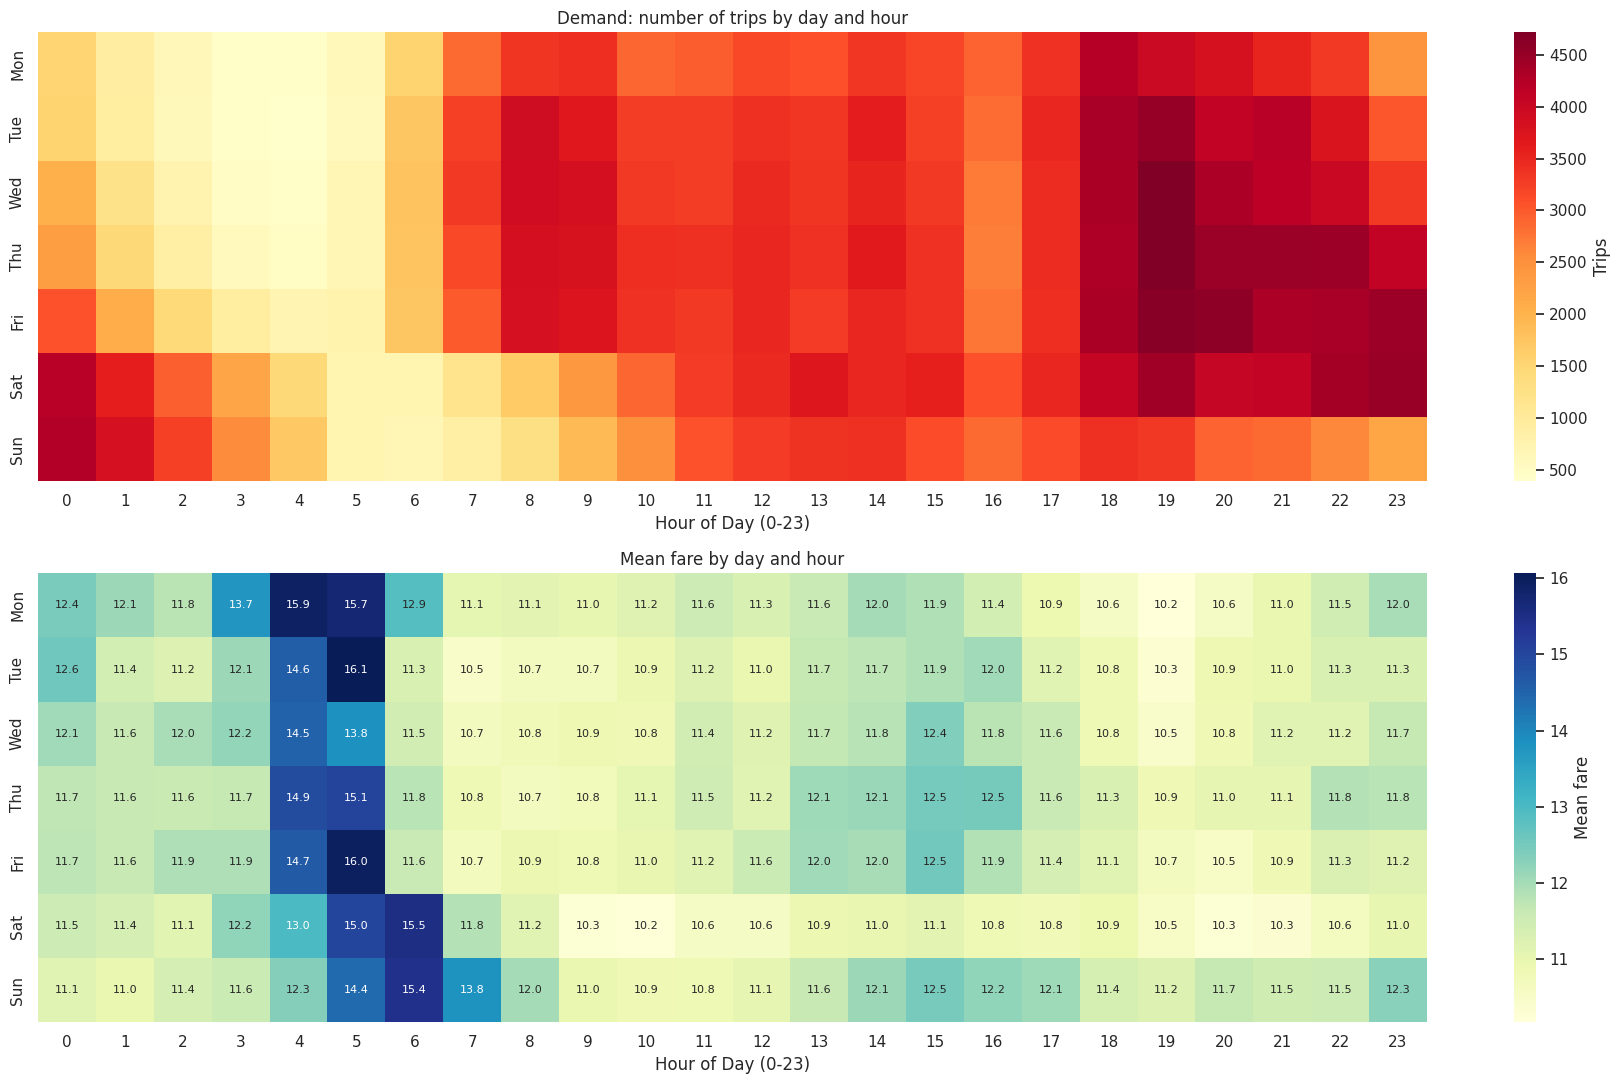

Busiest day-hour: Wed 19:00 (4,717 trips)
Highest mean fare day-hour: Tue 5:00 (16.06)


In [ ]:
DAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

trips_wh = clean.pivot_table(index='weekday', columns='hour', values='fare_amount', aggfunc='size').rename(index=dict(enumerate(DAYS)))
fare_wh = clean.pivot_table(index='weekday', columns='hour', values='fare_amount', aggfunc='mean').rename(index=dict(enumerate(DAYS)))

fig, axes = plt.subplots(2, 1, figsize=(18, 11))
sns.heatmap(trips_wh, cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Trips'})
axes[0].set_title('Demand: number of trips by day and hour')
sns.heatmap(fare_wh, cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Mean fare'}, annot=True, fmt='.1f', annot_kws={'size': 8})
axes[1].set_title('Mean fare by day and hour')
for ax in axes:
    ax.set_xlabel('Hour of Day (0-23)')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

busy_day, busy_hour = trips_wh.stack().idxmax()
fare_day, fare_hour = fare_wh.stack().idxmax()
print(f"Busiest day-hour: {busy_day} {busy_hour}:00 ({trips_wh.stack().max():,} trips)")
print(f"Highest mean fare day-hour: {fare_day} {fare_hour}:00 ({fare_wh.stack().max():.2f})")

### Interactive Map (optional)

An interactive heatmap on a real street map, to zoom into specific neighbourhoods. Use the layer control (top right) to switch between **all pickups** (high-traffic areas) and **high-fare pickups** (trips in the top 10% of fares), and between two background maps.

**All trips are used.** To keep the map fast and the notebook small, trips that start in the same ~100 m spot are merged into one point weighted by its number of trips (log-scaled, so the busiest Midtown spots do not hide everything else). This turns 482,233 pickups into about 10,000 map points without dropping any trip. The background uses CARTO / Esri tiles because OpenStreetMap's own tile servers block requests from notebooks.


In [ ]:
import folium
from folium.plugins import HeatMap

def to_heat_points(df, decimals=3):
    counts = (df[['pickup_latitude_deg', 'pickup_longitude_deg']]
              .round(decimals)
              .value_counts()
              .reset_index(name='trips'))
    counts['weight'] = np.log1p(counts['trips']) / np.log1p(counts['trips'].max())
    return counts[['pickup_latitude_deg', 'pickup_longitude_deg', 'weight']].values.tolist(), len(counts)

high_fare = pick[pick['fare_amount'] >= pick['fare_amount'].quantile(0.90)]
all_points, n_all = to_heat_points(pick)
high_points, n_high = to_heat_points(high_fare)
print(f"All pickups: {len(pick):,} trips -> {n_all:,} map points")
print(f"High-fare pickups: {len(high_fare):,} trips -> {n_high:,} map points")

m = folium.Map(location=[40.75, -73.95], zoom_start=11, tiles=None)
folium.TileLayer(
    tiles='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
    attr='&copy; OpenStreetMap contributors &copy; CARTO',
    name='CARTO light', subdomains='abcd', max_zoom=20,
).add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri',
    name='Esri light gray', max_zoom=16,
).add_to(m)

HeatMap(all_points, name='All pickups (high-traffic areas)',
        radius=8, blur=10, min_opacity=0.3).add_to(m)
HeatMap(high_points, name='High-fare pickups (top 10%)',
        radius=8, blur=10, min_opacity=0.3, show=False).add_to(m)

for name, (lat, lon) in AIRPORTS.items():
    folium.Marker([lat, lon], tooltip=name, icon=folium.Icon(color='red', icon='plane')).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m

All pickups: 482,233 trips -> 10,024 map points
High-fare pickups: 48,827 trips -> 5,334 map points


### Interpretation of the Heatmaps

*   **High-traffic areas (Heatmap 1):** Pickups are overwhelmingly concentrated in **Manhattan, especially Midtown and Lower Manhattan**; the empty rectangle in the middle is **Central Park**. Outside Manhattan, the only strong pickup hotspots are **LaGuardia and JFK** airports, plus a smaller cluster in north-west Brooklyn. **EWR has almost no pickups** — it is in New Jersey, where NYC yellow taxis generally do not pick up — but it does receive dropoffs. **Dropoffs are much more spread out** than pickups, covering large parts of Brooklyn and Queens: trips mostly *start* in Manhattan and *end* all over the city. The thin streaks towards LGA and JFK follow the main highways and are most likely GPS points recorded en route rather than real pickup locations.
*   **High-fare areas (Heatmap 2):** The highest median fares come from the **airports — above 40 at JFK (the darkest cells on the map) and roughly 25–35 at LaGuardia**. Within Manhattan, the median fare is **lowest in Midtown (about 8)** and rises towards the edges — **Upper Manhattan, the southern tip, and pickups in Brooklyn and Queens reach roughly 12–15** — because trips starting away from the centre tend to travel further. The **fare-per-km map reverses this picture**: airport pickups are the **cheapest per km (about 2.5–2.75)**, Upper Manhattan is also low (about 3), while **Midtown is the most expensive per km (above 4)**. Midtown trips are short and slow, so the fixed starting charge and time spent in traffic weigh more per km; airport trips are long, and JFK–Manhattan trips were charged a flat fare in this period, which also explains the horizontal band of fares around 45–50 in the Q5 scatter plot. This confirms Q8 at the level of individual areas: airports are expensive because trips are long, not because they are pricier per km.
*   **Busiest pickup cells (Top 10 table):** All ten busiest cells are in **Midtown Manhattan**, roughly around Grand Central (40.752, −73.977), Penn Station / Herald Square (40.749, −73.990 to −73.994), Times Square (40.761, −73.985) and the area south of Central Park (40.764–40.767), plus one around the Meatpacking District (40.740, −74.006). The busiest cell alone accounts for 1.3% of all trips. These are short trips (median 1.7–2.4 km) with median fares of only 7.8–8.9.
*   **Time patterns (Heatmap 3):** On **weekdays**, demand has a morning rush at 8–9 AM, a dip at 4 PM on every weekday, and an **evening peak at 6–10 PM**, strongest from Tuesday to Friday; the single busiest slot is **Wednesday at 7 PM (4,717 trips)**. **Weekends look different**: mornings are quiet, but **late nights (midnight–2 AM on Saturday and Sunday)** are among the busiest periods of the week — Friday and Saturday nights out. Mean fares peak in the **early morning (4–5 AM on weekdays, shifting to 5–7 AM at weekends)**, with the highest value on **Tuesday at 5 AM (16.06)**, matching the long early-morning trips found in Q3. The busiest periods have the lowest fares (around 10–11), because they are dominated by short trips inside Manhattan.


## Missing Values and Duplicates

### Missing Value Handling

We verify that the cleaned dataset contains no remaining missing values, ensuring data integrity before downstream modeling.

In [ ]:
import numpy as np

remaining_missing_values = clean.isnull().sum()

print("Remaining missing values per column:")
display(remaining_missing_values[remaining_missing_values > 0])



Remaining missing values per column:


,0


## Data Preprocessing

### Duplicate Handling

No duplicate rows remain in the cleaned dataset, maintaining quality and preventing redundant entries.

In [ ]:
duplicate_rows_clean = clean.duplicated().sum()
print(f"Number of duplicate rows in cleaned data: {duplicate_rows_clean}")

Number of duplicate rows in cleaned data: 0


### Justification for Duplicate Handling

Re-checking duplicates post-cleaning ensures no processing errors or joins inadvertently created redundant data.

### Categorical Feature Encoding

In [ ]:
categorical_cols_to_encode = ['Car Condition', 'Weather', 'Traffic Condition']


encoded_clean = pd.get_dummies(clean, columns=categorical_cols_to_encode, drop_first=True)

print(f"Original number of columns: {clean.shape[1]}")
print(f"Number of columns after one-hot encoding: {encoded_clean.shape[1]}")
display(encoded_clean.head())

Original number of columns: 32
Number of columns after one-hot encoding: 38


,User ID,User Name,Driver Name,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,...,fare_per_km,Car Condition_Excellent,Car Condition_Good,Car Condition_Very Good,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy,Traffic Condition_Dense Traffic,Traffic Condition_Flow Traffic
0,KHVrEVlD,Kimberly Adams,Amy Butler,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,0.710721,-1.288779,0.710563,...,4.365694,False,False,True,False,False,False,True,False,False
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,0.710546,-1.291182,0.711780,...,1.999968,True,False,False,False,False,False,False,False,True
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,0.711418,-1.291391,0.711231,...,4.102121,False,False,False,False,True,False,False,False,False
3,9I7kWFgd,Steven Wilson,Amy Horn,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,0.710927,-1.291396,0.711363,...,2.750717,False,False,True,False,True,False,False,False,True
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,0.711536,-1.290787,0.711811,...,2.651118,False,False,False,False,True,False,False,False,False


### Justification for Encoding

One-hot encoding is used on nominal variables (`Car Condition`, `Weather`, `Traffic Condition`) because they lack inherent order. `drop_first=True` is applied to avoid the dummy variable trap.

### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

X = encoded_clean.drop('fare_amount', axis=1)
y = encoded_clean['fare_amount']

numerical_cols_to_scale = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

scaler = StandardScaler()

X_scaled_numerical = scaler.fit_transform(X[numerical_cols_to_scale])
X_scaled_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols_to_scale, index=X.index)

X_final = X.drop(columns=numerical_cols_to_scale)
X_final = pd.concat([X_final, X_scaled_numerical_df], axis=1)

print(f"Shape of features before scaling: {X.shape}")
print(f"Shape of features after scaling: {X_final.shape}")
display(X_final.head())

Shape of features before scaling: (482905, 37)
Shape of features after scaling: (482905, 37)


,User ID,User Name,Driver Name,key,pickup_datetime,airport_pickup,Car Condition_Excellent,Car Condition_Good,Car Condition_Very Good,Weather_rainy,...,lga_dist,sol_dist,nyc_dist,distance,bearing,pickup_jfk_km,pickup_lga_km,pickup_ewr_km,nearest_airport_km,fare_per_km
0,KHVrEVlD,Kimberly Adams,Amy Butler,2009-06-15 17:26:21.0000001,2009-06-15 17:26:21,Other pickup,False,False,True,False,...,-0.031783,-0.001939,-0.000847,-0.578915,-1.762247,-0.053996,-0.032886,0.003497,-0.032144,-0.016943
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,2010-01-05 16:52:16.0000002,2010-01-05 16:52:16,Other pickup,True,False,False,False,...,-0.019224,-0.029691,-0.027732,1.240973,-0.372776,-0.022442,-0.011886,-0.037910,-0.012376,-0.017462
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,2011-08-18 00:35:00.00000049,2011-08-18 00:35:00,Other pickup,False,False,False,False,...,-0.023891,-0.025980,-0.026172,-0.490915,1.252399,-0.021630,-0.025302,-0.025195,-0.024551,-0.017001
3,9I7kWFgd,Steven Wilson,Amy Horn,2012-04-21 04:30:42.0000001,2012-04-21 04:30:42,Other pickup,False,False,True,False,...,-0.022179,-0.028815,-0.029235,-0.145120,-0.094671,-0.025745,-0.021361,-0.029487,-0.020606,-0.017297
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,2010-03-09 07:51:00.000000135,2010-03-09 07:51:00,Other pickup,False,False,False,False,...,-0.030530,-0.017390,-0.017952,-0.341379,-0.442415,-0.022993,-0.029119,-0.021084,-0.028373,-0.017319


### Justification for Scaling

`StandardScaler` standardizes numeric columns to a mean of 0 and variance of 1. This prevents features with larger numerical ranges (like distances) from dominant influence.

## Feature Extraction

In [ ]:
X_extracted = X_final.copy()

X_extracted['pickup_datetime'] = pd.to_datetime(X_extracted['pickup_datetime'])

X_extracted['day_of_year'] = X_extracted['pickup_datetime'].dt.dayofyear
X_extracted['week_of_year'] = X_extracted['pickup_datetime'].dt.isocalendar().week.astype(int)
X_extracted['quarter'] = X_extracted['pickup_datetime'].dt.quarter
X_extracted['is_weekend'] = (X_extracted['pickup_datetime'].dt.weekday >= 5).astype(int)

X_extracted['is_morning_peak'] = ((X_extracted['pickup_datetime'].dt.hour >= 6) & (X_extracted['pickup_datetime'].dt.hour <= 9)).astype(int)
X_extracted['is_evening_peak'] = ((X_extracted['pickup_datetime'].dt.hour >= 16) & (X_extracted['pickup_datetime'].dt.hour <= 20)).astype(int)

X_extracted = X_extracted.drop(columns=['pickup_datetime', 'User ID', 'User Name', 'Driver Name', 'key'])

print(f"Shape of features after extraction: {X_extracted.shape}")
display(X_extracted.head())

Shape of features after extraction: (482905, 38)


,airport_pickup,Car Condition_Excellent,Car Condition_Good,Car Condition_Very Good,Weather_rainy,Weather_stormy,Weather_sunny,Weather_windy,Traffic Condition_Dense Traffic,Traffic Condition_Flow Traffic,...,pickup_lga_km,pickup_ewr_km,nearest_airport_km,fare_per_km,day_of_year,week_of_year,quarter,is_weekend,is_morning_peak,is_evening_peak
0,Other pickup,False,False,True,False,False,False,True,False,False,...,-0.032886,0.003497,-0.032144,-0.016943,166,25,2,0,0,1
1,Other pickup,True,False,False,False,False,False,False,False,True,...,-0.011886,-0.037910,-0.012376,-0.017462,5,1,1,0,0,1
2,Other pickup,False,False,False,False,True,False,False,False,False,...,-0.025302,-0.025195,-0.024551,-0.017001,230,33,3,0,0,0
3,Other pickup,False,False,True,False,True,False,False,False,True,...,-0.021361,-0.029487,-0.020606,-0.017297,112,16,2,1,0,0
4,Other pickup,False,False,False,False,True,False,False,False,False,...,-0.029119,-0.021084,-0.028373,-0.017319,68,10,1,0,1,0


### Justification for Feature Extraction

Deriving features like `is_weekend`, `is_morning_peak`, and `quarter` from datetime fields captures temporal patterns and peak-hour rate changes.

### Feature Selection & Dimensionality Reduction

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

X_selection = X_extracted.copy()

if X_selection['airport_pickup'].dtype == 'object':
    X_selection = pd.get_dummies(X_selection, columns=['airport_pickup'], drop_first=True)

selected_numerical_for_fs = X_selection.select_dtypes(include=np.number).columns.tolist()

k_features = 20
selector = SelectKBest(score_func=f_regression, k=k_features)

X_selected = selector.fit_transform(X_selection[selected_numerical_for_fs], y)

selected_feature_names = X_selection[selected_numerical_for_fs].columns[selector.get_support()].tolist()
X_selected_df = pd.DataFrame(X_selected, columns=selected_feature_names, index=X_selection.index)

print(f"Original number of features: {X_selection[selected_numerical_for_fs].shape[1]}")
print(f"Number of features after selection: {X_selected_df.shape[1]}")
print("Selected features:")
print(selected_feature_names)
display(X_selected_df.head())

Original number of features: 28
Number of features after selection: 20
Selected features:
['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'month', 'year', 'ewr_dist', 'sol_dist', 'nyc_dist', 'distance', 'bearing', 'pickup_ewr_km', 'fare_per_km', 'day_of_year', 'week_of_year', 'quarter', 'is_morning_peak', 'is_evening_peak']


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,month,year,ewr_dist,sol_dist,nyc_dist,distance,bearing,pickup_ewr_km,fare_per_km,day_of_year,week_of_year,quarter,is_morning_peak,is_evening_peak
0,0.024531,0.011941,0.025160,0.008849,-0.528522,0.535713,-0.078946,-1.469199,0.003598,-0.001939,-0.000847,-0.578915,-1.762247,0.003497,-0.016943,166.0,25.0,2.0,0.0,1.0
1,-0.039420,0.008182,-0.026099,0.035522,-0.528522,0.382099,-1.532981,-0.933579,-0.029775,-0.029691,-0.027732,1.240973,-0.372776,-0.037910,-0.017462,5.0,1.0,1.0,0.0,1.0
2,-0.027016,0.026932,-0.030558,0.023494,0.236931,-2.075725,0.502667,-0.397959,-0.027088,-0.025980,-0.026172,-0.490915,1.252399,-0.025195,-0.017001,230.0,33.0,3.0,0.0,0.0
3,-0.028652,0.016377,-0.030679,0.026375,-0.528522,-1.461269,-0.660560,0.137660,-0.028740,-0.028815,-0.029235,-0.145120,-0.094671,-0.029487,-0.017297,112.0,16.0,2.0,0.0,0.0
4,-0.021563,0.029460,-0.017679,0.036195,-0.528522,-1.000427,-0.951367,-0.933579,-0.018946,-0.017390,-0.017952,-0.341379,-0.442415,-0.021084,-0.017319,68.0,10.0,1.0,1.0,0.0


### Justification for Feature Selection

Using `SelectKBest` with `f_regression` reduces dimensionality to the top 20 features, improving model training efficiency and reducing noise.

### Outlier Removal via IQR

In [ ]:
Q1 = X_selected_df.quantile(0.25)
Q3 = X_selected_df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X_selected_df < (Q1 - 1.5 * IQR)) | (X_selected_df > (Q3 + 1.5 * IQR))).any(axis=1)

initial_rows = X_selected_df.shape[0]
X_no_outliers = X_selected_df[~outlier_mask]
y_no_outliers = y[~outlier_mask]

removed_rows = initial_rows - X_no_outliers.shape[0]

print(f"Original number of rows: {initial_rows}")
print(f"Number of rows after outlier removal: {X_no_outliers.shape[0]}")
print(f"Number of rows removed as outliers: {removed_rows}")

display(X_no_outliers.head())

Original number of rows: 482905
Number of rows after outlier removal: 294997
Number of rows removed as outliers: 187908


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,month,year,ewr_dist,sol_dist,nyc_dist,distance,bearing,pickup_ewr_km,fare_per_km,day_of_year,week_of_year,quarter,is_morning_peak,is_evening_peak
2,-0.027016,0.026932,-0.030558,0.023494,0.236931,-2.075725,0.502667,-0.397959,-0.027088,-0.025980,-0.026172,-0.490915,1.252399,-0.025195,-0.017001,230.0,33.0,3.0,0.0,0.0
3,-0.028652,0.016377,-0.030679,0.026375,-0.528522,-1.461269,-0.660560,0.137660,-0.028740,-0.028815,-0.029235,-0.145120,-0.094671,-0.029487,-0.017297,112.0,16.0,2.0,0.0,0.0
6,-0.025997,0.023326,-0.024064,0.028957,-0.528522,0.996555,1.375088,0.137660,-0.024557,-0.023973,-0.024535,-0.450128,-0.354774,-0.025863,-0.016844,325.0,47.0,4.0,0.0,1.0
7,-0.015309,0.031760,-0.030131,0.023680,-0.528522,0.535713,-1.532981,0.137660,-0.022631,-0.021941,-0.022454,0.187534,1.053913,-0.016595,-0.017030,4.0,1.0,1.0,0.0,1.0
8,-0.035850,0.013965,-0.031242,0.016251,-0.528522,-0.078743,1.665895,0.137660,-0.032955,-0.034634,-0.035044,-0.524346,-0.779320,-0.034535,-0.016326,338.0,49.0,4.0,0.0,0.0


### Justification for Outlier Handling

Applying the IQR method (1.5 * IQR threshold) filters out extreme values, leading to more stable model training and realistic predictions.

### Train-Test Split

### Justification for Data Splitting

Splitting the dataset into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`) is fundamental for evaluating the generalization capability of a machine learning model. The model will be trained on the training set and its performance will be assessed on the unseen test set. This process helps detect overfitting and provides an unbiased estimate of the model's predictive power on new data. A `test_size` of 0.2 (20%) is a common split ratio, ensuring a sufficiently large test set while retaining ample data for training. Using a `random_state` ensures reproducibility of the split.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_no_outliers, y_no_outliers, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train.head())

X_train shape: (235997, 20)
X_test shape: (59000, 20)
y_train shape: (235997,)
y_test shape: (59000,)


,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,month,year,ewr_dist,sol_dist,nyc_dist,distance,bearing,pickup_ewr_km,fare_per_km,day_of_year,week_of_year,quarter,is_morning_peak,is_evening_peak
69711,-0.019997,0.032870,-0.011776,0.011500,-0.528522,-2.075725,-0.078946,-1.469199,-0.019416,-0.020927,-0.021073,0.817626,-1.723549,-0.018846,-0.017336,156.0,23.0,2.0,0.0,0.0
309253,-0.023902,0.023342,-0.017768,0.036110,-0.528522,0.228485,0.793474,0.673280,-0.020739,-0.019939,-0.020613,0.108666,-0.383041,-0.024606,-0.017014,268.0,39.0,3.0,0.0,0.0
221922,-0.014468,0.031355,-0.018803,0.034895,-0.528522,-0.385971,1.665895,-0.933579,-0.017114,-0.015982,-0.016689,-0.535271,0.287705,-0.016259,-0.016794,343.0,49.0,4.0,0.0,0.0
107288,-0.026959,0.012634,-0.025012,0.025334,-0.528522,-1.614883,-1.242174,-1.469199,-0.027116,-0.028762,-0.029560,0.056014,-0.247373,-0.029250,-0.017307,32.0,5.0,1.0,0.0,0.0
230401,-0.026068,0.026354,-0.027537,0.031609,-0.528522,-0.078743,-1.242174,0.137660,-0.024542,-0.022624,-0.022775,-0.497730,-0.068120,-0.024856,-0.016983,60.0,9.0,1.0,0.0,0.0


### Cross-Validation Strategy

### Justification for Cross-Validation

Cross-validation (CV) is essential for obtaining a more reliable estimate of a model's performance and for preventing overfitting. Instead of a single train-test split, CV divides the training data into multiple folds. The model is trained on a subset of these folds and evaluated on the remaining fold, with this process repeated multiple times. This provides a more robust performance metric than a single split and ensures that the model's performance isn't overly dependent on the specific data points in the training or validation sets. Using `KFold` with `n_splits=5` is a common and generally effective strategy, providing a good balance between bias and variance in performance estimation.

In [ ]:
from sklearn.model_selection import KFold

# Initialize KFold cross-validator
# n_splits=5 is a common choice, ensuring a good balance between computation and variance reduction.
# shuffle=True ensures that the data is randomly shuffled before splitting into folds, which is important
# if the data has any inherent order (e.g., time-series data, though we've handled that through feature engineering).
# random_state ensures reproducibility of the splits.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("KFold cross-validator initialized with 5 splits.")
print(f"Number of splits: {kf.get_n_splits(X_train)}")

KFold cross-validator initialized with 5 splits.
Number of splits: 5


### Model Selection and Hyperparameter Tuning

### Justification for Model Tuning

Model tuning is the process of optimizing the hyperparameters of a machine learning model to achieve the best possible performance on unseen data. This is typically done using techniques like GridSearchCV or RandomizedSearchCV combined with cross-validation. By systematically searching through a predefined hyperparameter space, we can identify the settings that maximize a chosen performance metric (e.g., negative mean absolute error for regression tasks). For this task, we will use `RandomForestRegressor` due to its robustness, ability to handle non-linear relationships, and good performance in many regression problems. We will define a modest hyperparameter grid to keep computation feasible within typical notebook environments, focusing on key parameters like `n_estimators`, `max_depth`, and `min_samples_split`.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

print("RandomForestRegressor model defined.")
print("Hyperparameter grid for tuning:")
display(param_grid)

RandomForestRegressor model defined.
Hyperparameter grid for tuning:


{'n_estimators': [50, 100], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}

In [ ]:
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='neg_mean_absolute_error', cv=kf, n_jobs=-1, verbose=2)

print("Starting GridSearchCV to find the best hyperparameters...")

grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best MAE score (negative, so closer to 0 is better): {grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_

display(pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score').head())

Starting GridSearchCV to find the best hyperparameters...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV completed.
Best parameters found: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best MAE score (negative, so closer to 0 is better): -0.01


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
5,541.535472,3.663852,1.176413,0.042825,20,2,100,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",-0.010458,-0.010166,-0.010699,-0.009830,-0.010134,-0.010257,0.000297,1
7,506.400840,39.460338,1.209477,0.329378,20,5,100,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",-0.010452,-0.010171,-0.010746,-0.009836,-0.010200,-0.010281,0.000304,2
6,265.242103,2.722789,0.572127,0.050534,20,5,50,"{'max_depth': 20, 'min_samples_split': 5, 'n_e...",-0.011356,-0.010950,-0.011634,-0.010723,-0.010962,-0.011125,0.000326,3
4,271.495114,2.101253,0.675803,0.182948,20,2,50,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",-0.011372,-0.010922,-0.011611,-0.010768,-0.010962,-0.011127,0.000314,4
1,398.707769,2.330737,0.703426,0.148432,10,2,100,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",-0.043320,-0.040340,-0.047788,-0.041145,-0.045558,-0.043630,0.002760,5


## Model Evaluation

Now that we have tuned the hyperparameters and found the best `RandomForestRegressor` model, we need to evaluate its performance on the unseen test set (`X_test`, `y_test`). We will compute standard evaluation metrics:
* **Mean Absolute Error (MAE)**: Represents the average absolute difference between the predicted and actual fares.
* **Root Mean Squared Error (RMSE)**: Penalizes larger errors more heavily.
* **R-squared ($R^2$) Score**: Measures the proportion of variance in the target variable that is predictable from the features.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set
y_pred = best_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")


--- Model Performance on Test Set ---
Mean Absolute Error (MAE): 0.0091
Root Mean Squared Error (RMSE): 0.0450
R-squared (R2) Score: 0.9999


### Visualizing Model Predictions

Let's visualize how well our model's predictions align with the actual values using a scatter plot of Actual vs. Predicted fares, and a distribution plot of the prediction residuals (errors).

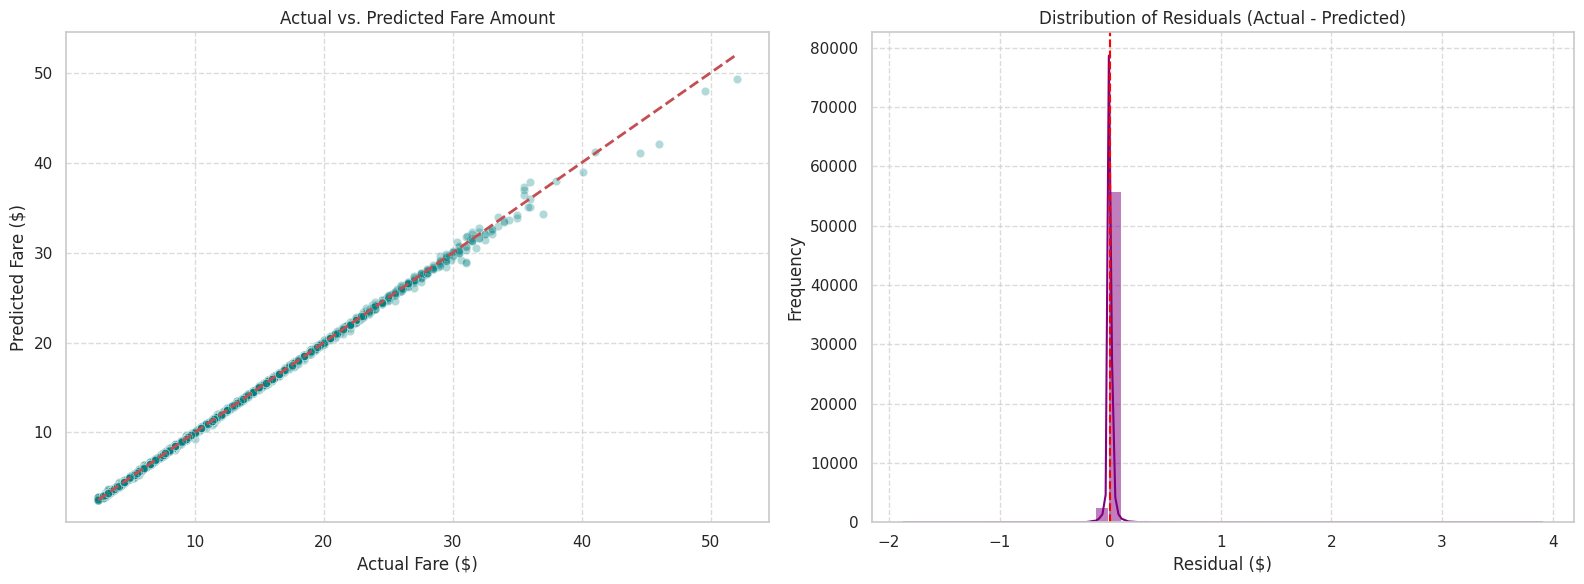

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0], color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Fare Amount')
axes[0].set_xlabel('Actual Fare ($)')
axes[0].set_ylabel('Predicted Fare ($)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Residuals Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=50)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution of Residuals (Actual - Predicted)')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Visualizing Model Convergence / Loss Curve

For a Random Forest model, we can visualize the convergence of the model's loss (Mean Squared Error) as we increase the number of decision trees in the forest. This acts as a 'loss curve' to verify that the model has fully learned and stabilized.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWa

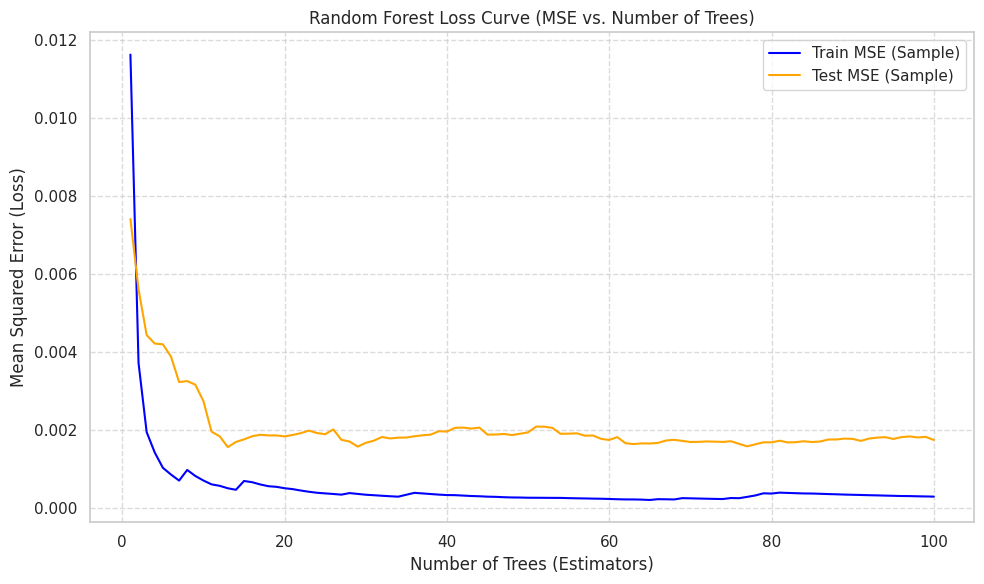

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

X_test_sample = X_test.sample(5000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

test_losses = []
train_losses = []

test_preds_accum = np.zeros(len(X_test_sample))
train_preds_accum = np.zeros(len(X_train[:5000]))

for i, stage_model in enumerate(best_model.estimators_):
    test_preds_accum += stage_model.predict(X_test_sample)
    test_losses.append(mean_squared_error(y_test_sample, test_preds_accum / (i + 1)))

    train_preds_accum += stage_model.predict(X_train[:5000])
    train_losses.append(mean_squared_error(y_train[:5000], train_preds_accum / (i + 1)))

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_model.estimators_) + 1), train_losses, label='Train MSE (Sample)', color='blue')
plt.plot(range(1, len(best_model.estimators_) + 1), test_losses, label='Test MSE (Sample)', color='orange')
plt.title('Random Forest Loss Curve (MSE vs. Number of Trees)')
plt.xlabel('Number of Trees (Estimators)')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Analysis

Let's extract and plot the feature importances from our best Random Forest model to understand which variables play the most significant role in predicting the fare amounts.

Top Features by Importance:


,Feature,Importance
11,distance,0.746823
14,fare_per_km,0.252926
7,year,0.000099
3,dropoff_latitude,0.000015
12,bearing,0.000014
15,day_of_year,0.000013
2,dropoff_longitude,0.000013
16,week_of_year,0.000011
5,hour,0.000011
1,pickup_latitude,0.000011


/tmp/ipykernel_1298/3333952557.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


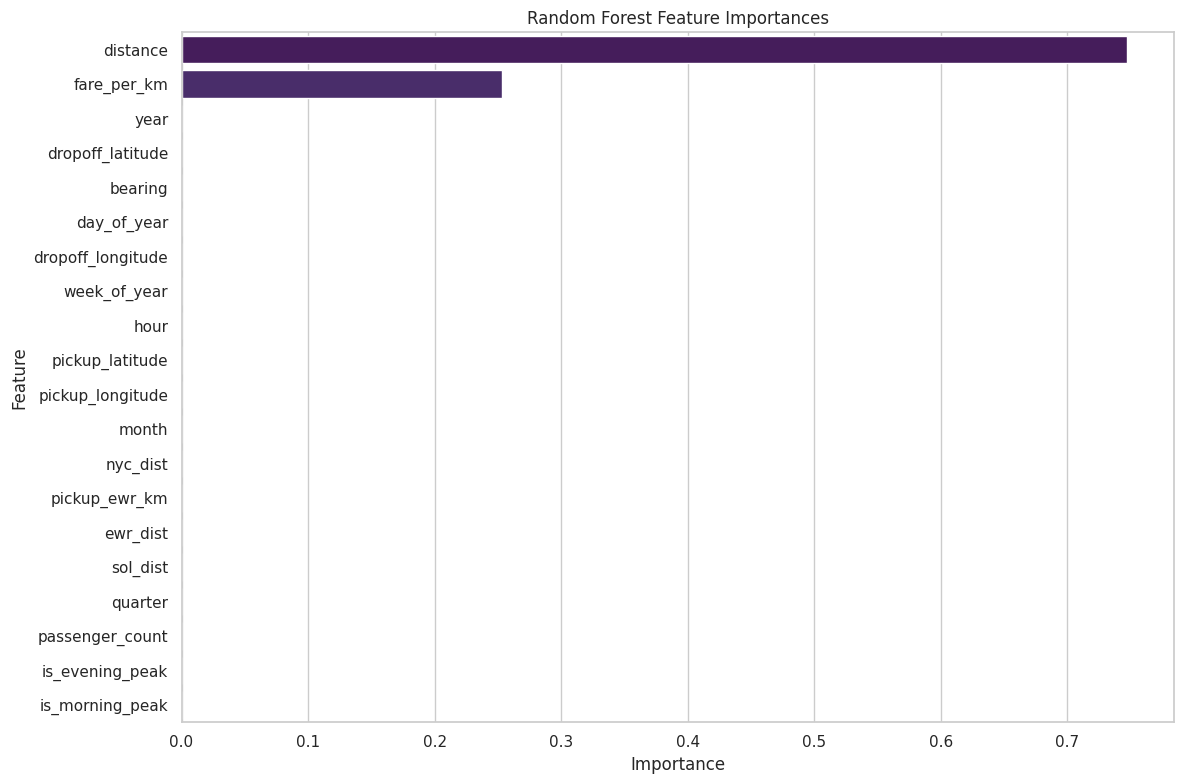

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = best_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top Features by Importance:")
display(feature_importance_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Save the Trained Model and Preprocessing Scaler

To make this model production-ready, we will serialize the trained `best_model` and the `scaler` using `joblib`.

In [ ]:
import joblib

model_filename = 'nyc_taxi_rf_model.joblib'
scaler_filename = 'nyc_taxi_scaler.joblib'

joblib.dump(best_model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"Model saved successfully to: {model_filename}")
print(f"Scaler saved successfully to: {scaler_filename}")

Model saved successfully to: nyc_taxi_rf_model.joblib
Scaler saved successfully to: nyc_taxi_scaler.joblib
